## Install Required Libraries

In [4]:
!pip install numpy scikit-learn pyts torch matplotlib sktime==0.30.0 --quiet
!pip install git+https://github.com/gon-uri/detach_rocket --quiet

  ERROR: Error [WinError 2] The system cannot find the file specified while executing command git version
ERROR: Cannot find command 'git' - do you have 'git' installed and in your PATH?


## Download Dataset from UCR

In [5]:
from detach_rocket.utils_datasets import fetch_ucr_dataset

# Download Dataset
dataset_name_list = ['FordB'] # PhalangesOutlinesCorrect ProximalPhalanxOutlineCorrect #Fordb
current_dataset = fetch_ucr_dataset(dataset_name_list[0])

In [6]:
print(type(current_dataset))
print(current_dataset.keys())

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data_train', 'target_train', 'data_test', 'target_test', 'DESCR', 'url'])


In [7]:
print("X_train shape:", current_dataset.data_train.shape)
print("y_train shape:", current_dataset.target_train.shape)

print("X_test shape:", current_dataset.data_test.shape)
print("y_test shape:", current_dataset.target_test.shape)

X_train shape: (3636, 500)
y_train shape: (3636,)
X_test shape: (810, 500)
y_test shape: (810,)


In [8]:
import numpy as np

print("Train classes:", np.unique(
    current_dataset.target_train,
    return_counts=True
))

print("Test classes:", np.unique(
    current_dataset.target_test,
    return_counts=True
))

Train classes: (array([-1,  1], dtype=int64), array([1860, 1776], dtype=int64))
Test classes: (array([-1,  1], dtype=int64), array([401, 409], dtype=int64))


In [9]:
X_train = current_dataset.data_train
y_train = current_dataset.target_train

X_test = current_dataset.data_test
y_test = current_dataset.target_test

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(3636, 500) (3636,)
(810, 500) (810,)


In [10]:
print("Missing values in X_train:", np.isnan(X_train).sum())
print("Missing values in X_test:", np.isnan(X_test).sum())

Missing values in X_train: 0
Missing values in X_test: 0


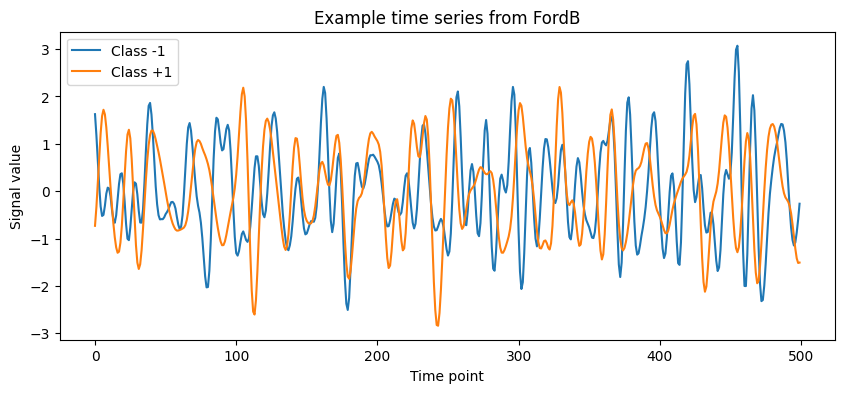

In [11]:
import matplotlib.pyplot as plt

idx_neg = np.where(y_train == -1)[0][0]
idx_pos = np.where(y_train == 1)[0][0]

plt.figure(figsize=(10, 4))
plt.plot(X_train[idx_neg], label="Class -1")
plt.plot(X_train[idx_pos], label="Class +1")
plt.xlabel("Time point")
plt.ylabel("Signal value")
plt.title("Example time series from FordB")
plt.legend()
plt.show()

In [12]:
X_train_rocket = X_train[:, np.newaxis, :]
X_test_rocket = X_test[:, np.newaxis, :]

print("X_train_rocket shape:", X_train_rocket.shape)
print("X_test_rocket shape:", X_test_rocket.shape)

X_train_rocket shape: (3636, 1, 500)
X_test_rocket shape: (810, 1, 500)


In [13]:
from sktime.transformations.panel.rocket import Rocket

rocket = Rocket(
    num_kernels=10_000,
    random_state=42
)

rocket.fit(X_train_rocket)

Z_train = rocket.transform(X_train_rocket)
Z_test = rocket.transform(X_test_rocket)

print("Z_train shape:", Z_train.shape)
print("Z_test shape:", Z_test.shape)

Z_train shape: (3636, 20000)
Z_test shape: (810, 20000)


In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import accuracy_score, f1_score
from time import perf_counter

scaler = StandardScaler()

Z_train_scaled = scaler.fit_transform(Z_train)
Z_test_scaled = scaler.transform(Z_test)

alphas = np.logspace(-3, 3, 10)

full_model = RidgeClassifierCV(alphas=alphas)

start = perf_counter()
full_model.fit(Z_train_scaled, y_train)
training_time = perf_counter() - start

start = perf_counter()
y_pred = full_model.predict(Z_test_scaled)
prediction_time = perf_counter() - start

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("Training time:", training_time)
print("Prediction time:", prediction_time)
print("Selected alpha:", full_model.alpha_)

Accuracy: 0.8024691358024691
F1-score: 0.8058252427184466
Training time: 6.767818599999828
Prediction time: 0.0989571000000069
Selected alpha: 1000.0


In [15]:
baseline_results = {
    "model": "Full ROCKET",
    "num_features": Z_train_scaled.shape[1],
    "accuracy": accuracy_score(y_test, y_pred),
    "f1_score": f1_score(y_test, y_pred),
    "training_time": training_time,
    "prediction_time": prediction_time,
    "alpha": full_model.alpha_
}

baseline_results

{'model': 'Full ROCKET',
 'num_features': 20000,
 'accuracy': 0.8024691358024691,
 'f1_score': 0.8058252427184466,
 'training_time': 6.767818599999828,
 'prediction_time': 0.0989571000000069,
 'alpha': 1000.0}

In [16]:
from sklearn.model_selection import train_test_split

Z_train_sub, Z_val, y_train_sub, y_val = train_test_split(
    Z_train_scaled,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Training subset:", Z_train_sub.shape, y_train_sub.shape)
print("Validation subset:", Z_val.shape, y_val.shape)
print("Test set:", Z_test_scaled.shape, y_test.shape)

Training subset: (2908, 20000) (2908,)
Validation subset: (728, 20000) (728,)
Test set: (810, 20000) (810,)


In [17]:
from detach_rocket.detach_classes import DetachMatrix
import inspect

print(inspect.signature(DetachMatrix))

(trade_off=0.1, recompute_alpha=True, val_ratio=0.33, verbose=False, multilabel_type='max', fixed_percentage=None)


In [18]:
print(inspect.signature(DetachMatrix.fit))

(self, X, y=None, val_set=None, val_set_y=None, X_test=None, y_test=None)


In [19]:
detach_model = DetachMatrix(
    trade_off=0.1,
    recompute_alpha=False,
    verbose=True
)

print(detach_model)

In [20]:
start = perf_counter()

detach_model.fit(
    Z_train_sub,
    y_train_sub,
    val_set=Z_val,
    val_set_y=y_val
)

detach_time = perf_counter() - start

print("Detach fitting time:", detach_time)

Fitting Full Model
TRAINING RESULTS Full Features:
Optimal Alpha Full Features: 4832.93
Train Accuraccy Full Features: 99.86%
-------------------------
Applying Sequential Feature Detachment
Step 1 out of 150
100.000% of features used
Step 2 out of 150
95.000% of features used
Step 3 out of 150
90.250% of features used
Step 4 out of 150
85.735% of features used
Step 5 out of 150
81.450% of features used
Step 6 out of 150
77.375% of features used
Step 7 out of 150
73.505% of features used
Step 8 out of 150
69.830% of features used
Step 9 out of 150
66.340% of features used
Step 10 out of 150
63.020% of features used
Step 11 out of 150
59.870% of features used
Step 12 out of 150
56.880% of features used
Step 13 out of 150
54.035% of features used
Step 14 out of 150
51.330% of features used
Step 15 out of 150
48.765% of features used
Step 16 out of 150
46.325% of features used
Step 17 out of 150
44.010% of features used
Step 18 out of 150
41.810% of features used
Step 19 out of 150
39.720

In [21]:
print([name for name in dir(detach_model) if not name.startswith("_")])

['fit', 'fit_fixed_percentage', 'fit_trade_off', 'fixed_percentage', 'multilabel_type', 'predict', 'recompute_alpha', 'score', 'trade_off', 'val_ratio', 'verbose']


In [22]:
start = perf_counter()

detach_pred = detach_model.predict(Z_test_scaled)

detach_prediction_time = perf_counter() - start

detach_accuracy = accuracy_score(y_test, detach_pred)
detach_f1 = f1_score(y_test, detach_pred)

print("DETACH Accuracy:", detach_accuracy)
print("DETACH F1-score:", detach_f1)
print("DETACH prediction time:", detach_prediction_time)

DETACH Accuracy: 0.8148148148148148
DETACH F1-score: 0.8152709359605911
DETACH prediction time: 0.07998299999985647


In [23]:
print(detach_model.__dict__.keys())

dict_keys(['_sfd_curve', '_scaler', '_classifier', '_acc_train', '_full_classifier', '_percentage_vector', '_feature_matrix', '_labels', '_feature_importance_matrix', '_full_model_alpha', '_max_index', '_max_percentage', '_is_fitted', '_optimal_computed', 'trade_off', 'val_ratio', 'recompute_alpha', 'verbose', 'multilabel_type', 'fixed_percentage', '_feature_matrix_val', '_feature_mask'])


In [24]:
selected_features = int(np.sum(detach_model._feature_mask))
total_features = len(detach_model._feature_mask)
retained_percentage = 100 * selected_features / total_features
reduction_percentage = 100 - retained_percentage

print("Selected features:", selected_features)
print("Total features:", total_features)
print("Retained percentage:", retained_percentage)
print("Feature reduction:", reduction_percentage)

Selected features: 789
Total features: 20000
Retained percentage: 3.945
Feature reduction: 96.055


In [25]:
detach_results = {
    "model": "DETACH-ROCKET",
    "num_features": selected_features,
    "retained_percentage": retained_percentage,
    "feature_reduction": reduction_percentage,
    "accuracy": detach_accuracy,
    "f1_score": detach_f1,
    "selection_time": detach_time,
    "prediction_time": detach_prediction_time
}

detach_results

{'model': 'DETACH-ROCKET',
 'num_features': 789,
 'retained_percentage': 3.945,
 'feature_reduction': 96.055,
 'accuracy': 0.8148148148148148,
 'f1_score': 0.8152709359605911,
 'selection_time': 39.52881649999995,
 'prediction_time': 0.07998299999985647}

In [26]:
import pandas as pd

comparison_df = pd.DataFrame([
    {
        "Model": "Full ROCKET",
        "Features": baseline_results["num_features"],
        "Accuracy": baseline_results["accuracy"],
        "F1-score": baseline_results["f1_score"],
        "Prediction Time": baseline_results["prediction_time"]
    },
    {
        "Model": "DETACH-ROCKET",
        "Features": detach_results["num_features"],
        "Accuracy": detach_results["accuracy"],
        "F1-score": detach_results["f1_score"],
        "Prediction Time": detach_results["prediction_time"]
    }
])

comparison_df

,Model,Features,Accuracy,F1-score,Prediction Time
0,Full ROCKET,20000,0.802469,0.805825,0.098957
1,DETACH-ROCKET,789,0.814815,0.815271,0.079983


In [27]:
comparison_df.to_csv("comparison_results.csv", index=False)
print("Saved successfully")

Saved successfully


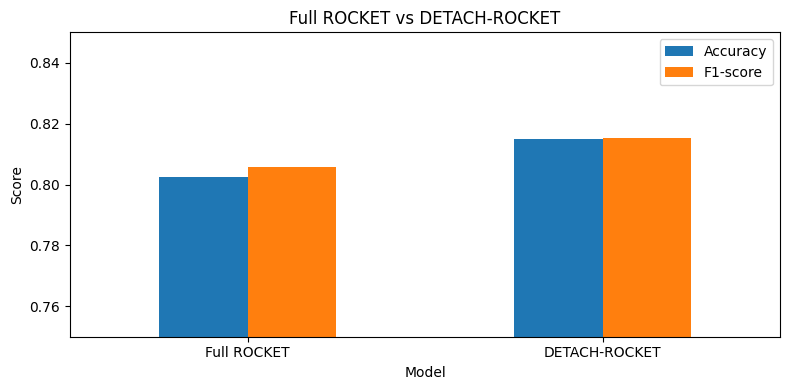

In [28]:
comparison_df.plot(
    x="Model",
    y=["Accuracy", "F1-score"],
    kind="bar",
    figsize=(8, 4)
)

plt.ylim(0.75, 0.85)
plt.ylabel("Score")
plt.title("Full ROCKET vs DETACH-ROCKET")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

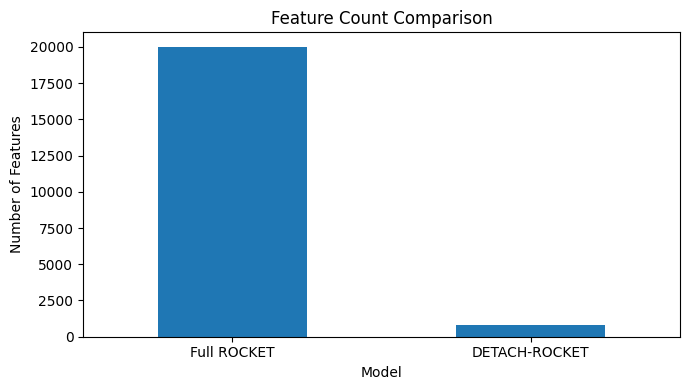

In [29]:
comparison_df.plot(
    x="Model",
    y="Features",
    kind="bar",
    figsize=(7, 4),
    legend=False
)

plt.ylabel("Number of Features")
plt.title("Feature Count Comparison")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

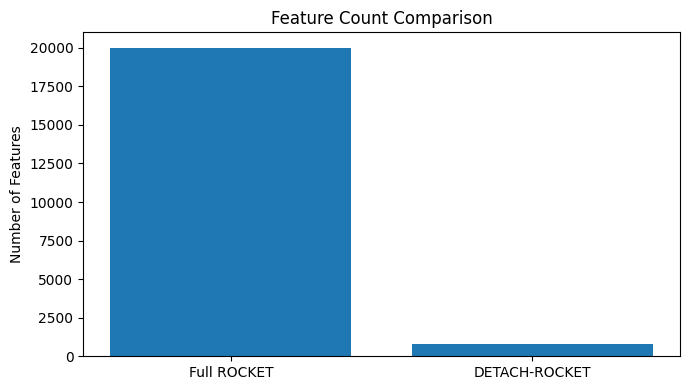

In [30]:
plt.figure(figsize=(7, 4))
plt.bar(
    comparison_df["Model"],
    comparison_df["Features"]
)

plt.ylabel("Number of Features")
plt.title("Feature Count Comparison")
plt.tight_layout()

plt.savefig(
    "feature_count_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [31]:
rng = np.random.default_rng(42)

random_feature_indices = rng.choice(
    Z_train_scaled.shape[1],
    size=selected_features,
    replace=False
)

print("Randomly selected features:", len(random_feature_indices))

Randomly selected features: 789


In [32]:
random_model = RidgeClassifierCV(alphas=alphas)

start = perf_counter()

random_model.fit(
    Z_train_scaled[:, random_feature_indices],
    y_train
)

random_training_time = perf_counter() - start

start = perf_counter()

random_pred = random_model.predict(
    Z_test_scaled[:, random_feature_indices]
)

random_prediction_time = perf_counter() - start

random_accuracy = accuracy_score(y_test, random_pred)
random_f1 = f1_score(y_test, random_pred)

print("Random Pruning Accuracy:", random_accuracy)
print("Random Pruning F1-score:", random_f1)
print("Random Pruning Training Time:", random_training_time)
print("Random Pruning Prediction Time:", random_prediction_time)
print("Selected Alpha:", random_model.alpha_)

Random Pruning Accuracy: 0.8
Random Pruning F1-score: 0.7975
Random Pruning Training Time: 0.6406684000000951
Random Pruning Prediction Time: 0.002735699999902863
Selected Alpha: 1000.0


In [33]:
random_results = {
    "model": "Random Pruning",
    "num_features": selected_features,
    "accuracy": random_accuracy,
    "f1_score": random_f1,
    "training_time": random_training_time,
    "prediction_time": random_prediction_time,
    "alpha": random_model.alpha_
}

random_results

{'model': 'Random Pruning',
 'num_features': 789,
 'accuracy': 0.8,
 'f1_score': 0.7975,
 'training_time': 0.6406684000000951,
 'prediction_time': 0.002735699999902863,
 'alpha': 1000.0}

In [34]:
comparison_df = pd.DataFrame([
    {
        "Model": "Full ROCKET",
        "Features": baseline_results["num_features"],
        "Accuracy": baseline_results["accuracy"],
        "F1-score": baseline_results["f1_score"],
        "Prediction Time": baseline_results["prediction_time"]
    },
    {
        "Model": "DETACH-ROCKET",
        "Features": detach_results["num_features"],
        "Accuracy": detach_results["accuracy"],
        "F1-score": detach_results["f1_score"],
        "Prediction Time": detach_results["prediction_time"]
    },
    {
        "Model": "Random Pruning",
        "Features": random_results["num_features"],
        "Accuracy": random_results["accuracy"],
        "F1-score": random_results["f1_score"],
        "Prediction Time": random_results["prediction_time"]
    }
])

comparison_df

,Model,Features,Accuracy,F1-score,Prediction Time
0,Full ROCKET,20000,0.802469,0.805825,0.098957
1,DETACH-ROCKET,789,0.814815,0.815271,0.079983
2,Random Pruning,789,0.800000,0.797500,0.002736


In [35]:
comparison_df.to_csv(
    "comparison_results_3_models.csv",
    index=False
)

print("Saved successfully")

Saved successfully


In [36]:
random_seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

print("Number of random runs:", len(random_seeds))

Number of random runs: 10


In [37]:
random_runs = []

for seed in random_seeds:
    rng = np.random.default_rng(seed)

    indices = rng.choice(
        Z_train_scaled.shape[1],
        size=selected_features,
        replace=False
    )

    model = RidgeClassifierCV(alphas=alphas)

    model.fit(
        Z_train_scaled[:, indices],
        y_train
    )

    predictions = model.predict(
        Z_test_scaled[:, indices]
    )

    random_runs.append({
        "seed": seed,
        "accuracy": accuracy_score(y_test, predictions),
        "f1_score": f1_score(y_test, predictions)
    })

print("Completed runs:", len(random_runs))

Completed runs: 10


In [38]:
random_runs_df = pd.DataFrame(random_runs)

print(random_runs_df)

print("\nMean Accuracy:", random_runs_df["accuracy"].mean())
print("Std Accuracy:", random_runs_df["accuracy"].std())

print("\nMean F1-score:", random_runs_df["f1_score"].mean())
print("Std F1-score:", random_runs_df["f1_score"].std())

   seed  accuracy  f1_score
0     0  0.804938  0.800505
1     1  0.787654  0.786600
2     2  0.795062  0.795567
3     3  0.774074  0.774908
4     4  0.788889  0.789149
5     5  0.793827  0.792030
6     6  0.785185  0.785185
7     7  0.782716  0.780549
8     8  0.793827  0.798065
9     9  0.801235  0.800000

Mean Accuracy: 0.7907407407407407
Std Accuracy: 0.009039457875098285

Mean F1-score: 0.790255799462978
Std F1-score: 0.008579203172164738


In [39]:
random_runs_df.to_csv(
    "random_pruning_10_runs.csv",
    index=False
)

print("Random runs saved successfully")

Random runs saved successfully


In [40]:
detach_seeds = [0, 1, 2, 3, 4]

print("Number of DETACH runs:", len(detach_seeds))

Number of DETACH runs: 5


In [41]:
detach_runs = []

print("Result container is ready.")

Result container is ready.


In [42]:
seed = detach_seeds[0]

print("Running seed:", seed)

# 1) ساخت ROCKET جدید با seed متفاوت
rocket_seed = Rocket(
    num_kernels=10_000,
    random_state=seed
)

rocket_seed.fit(X_train_rocket)

# 2) تولید ۲۰هزار ویژگی جدید
Z_train_seed = rocket_seed.transform(X_train_rocket)
Z_test_seed = rocket_seed.transform(X_test_rocket)

# 3) استانداردسازی ویژگی‌ها
scaler_seed = StandardScaler()

Z_train_seed_scaled = scaler_seed.fit_transform(Z_train_seed)
Z_test_seed_scaled = scaler_seed.transform(Z_test_seed)

# 4) جداسازی Train و Validation
Z_sub_seed, Z_val_seed, y_sub_seed, y_val_seed = train_test_split(
    Z_train_seed_scaled,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Prepared shapes:")
print(Z_sub_seed.shape)
print(Z_val_seed.shape)
print(Z_test_seed_scaled.shape)

Running seed: 0
Prepared shapes:
(2908, 20000)
(728, 20000)
(810, 20000)


In [43]:
detach_seed_model = DetachMatrix(
    trade_off=0.1,
    recompute_alpha=False,
    verbose=True
)

detach_seed_model.fit(
    Z_sub_seed,
    y_sub_seed,
    Z_val_seed,
    y_val_seed
)

print("DETACH seed 0 fitted successfully.")

Fitting Full Model


TRAINING RESULTS Full Features:
Optimal Alpha Full Features: 4832.93
Train Accuraccy Full Features: 99.83%
-------------------------
Applying Sequential Feature Detachment
Step 1 out of 150
100.000% of features used
Step 2 out of 150
95.000% of features used
Step 3 out of 150
90.250% of features used
Step 4 out of 150
85.735% of features used
Step 5 out of 150
81.450% of features used
Step 6 out of 150
77.375% of features used
Step 7 out of 150
73.505% of features used
Step 8 out of 150
69.830% of features used
Step 9 out of 150
66.340% of features used
Step 10 out of 150
63.020% of features used
Step 11 out of 150
59.870% of features used
Step 12 out of 150
56.880% of features used
Step 13 out of 150
54.035% of features used
Step 14 out of 150
51.330% of features used
Step 15 out of 150
48.765% of features used
Step 16 out of 150
46.325% of features used
Step 17 out of 150
44.010% of features used
Step 18 out of 150
41.810% of features used
Step 19 out of 150
39.720% of features used


In [44]:
detach_seed_pred = detach_seed_model.predict(
    Z_test_seed_scaled
)

detach_seed_accuracy = accuracy_score(
    y_test,
    detach_seed_pred
)

detach_seed_f1 = f1_score(
    y_test,
    detach_seed_pred
)

print("DETACH seed 0 Accuracy:", detach_seed_accuracy)
print("DETACH seed 0 F1-score:", detach_seed_f1)

DETACH seed 0 Accuracy: 0.8135802469135802
DETACH seed 0 F1-score: 0.813810110974106


In [45]:
detach_runs.append({
    "seed": seed,
    "accuracy": detach_seed_accuracy,
    "f1_score": detach_seed_f1
})

print(detach_runs)

[{'seed': 0, 'accuracy': 0.8135802469135802, 'f1_score': 0.813810110974106}]


In [46]:
seed = detach_seeds[1]

print("Next DETACH seed:", seed)

Next DETACH seed: 1


In [47]:
rocket_seed = Rocket(
    num_kernels=10_000,
    random_state=seed
)

rocket_seed.fit(X_train_rocket)

Z_train_seed = rocket_seed.transform(X_train_rocket)
Z_test_seed = rocket_seed.transform(X_test_rocket)

scaler_seed = StandardScaler()

Z_train_seed_scaled = scaler_seed.fit_transform(Z_train_seed)
Z_test_seed_scaled = scaler_seed.transform(Z_test_seed)

Z_sub_seed, Z_val_seed, y_sub_seed, y_val_seed = train_test_split(
    Z_train_seed_scaled,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Prepared seed:", seed)
print(Z_sub_seed.shape)
print(Z_val_seed.shape)
print(Z_test_seed_scaled.shape)

Prepared seed: 1
(2908, 20000)
(728, 20000)
(810, 20000)


In [48]:
detach_seed_model = DetachMatrix(
    trade_off=0.1,
    recompute_alpha=False,
    verbose=True
)

detach_seed_model.fit(
    Z_sub_seed,
    y_sub_seed,
    Z_val_seed,
    y_val_seed
)

print("DETACH seed 1 fitted successfully.")

Fitting Full Model
TRAINING RESULTS Full Features:
Optimal Alpha Full Features: 4832.93
Train Accuraccy Full Features: 99.83%
-------------------------
Applying Sequential Feature Detachment
Step 1 out of 150
100.000% of features used
Step 2 out of 150
95.000% of features used
Step 3 out of 150
90.250% of features used
Step 4 out of 150
85.735% of features used
Step 5 out of 150
81.450% of features used
Step 6 out of 150
77.375% of features used
Step 7 out of 150
73.505% of features used
Step 8 out of 150
69.830% of features used
Step 9 out of 150
66.340% of features used
Step 10 out of 150
63.020% of features used
Step 11 out of 150
59.870% of features used
Step 12 out of 150
56.880% of features used
Step 13 out of 150
54.035% of features used
Step 14 out of 150
51.330% of features used
Step 15 out of 150
48.765% of features used
Step 16 out of 150
46.325% of features used
Step 17 out of 150
44.010% of features used
Step 18 out of 150
41.810% of features used
Step 19 out of 150
39.720

In [49]:
detach_seed_pred = detach_seed_model.predict(
    Z_test_seed_scaled
)

detach_seed_accuracy = accuracy_score(
    y_test,
    detach_seed_pred
)

detach_seed_f1 = f1_score(
    y_test,
    detach_seed_pred
)

print("DETACH seed 1 Accuracy:", detach_seed_accuracy)
print("DETACH seed 1 F1-score:", detach_seed_f1)

DETACH seed 1 Accuracy: 0.8012345679012346
DETACH seed 1 F1-score: 0.802937576499388


In [50]:
detach_runs.append({
    "seed": seed,
    "accuracy": detach_seed_accuracy,
    "f1_score": detach_seed_f1
})

print(detach_runs)

[{'seed': 0, 'accuracy': 0.8135802469135802, 'f1_score': 0.813810110974106}, {'seed': 1, 'accuracy': 0.8012345679012346, 'f1_score': 0.802937576499388}]


In [51]:
seed = detach_seeds[2]

print("Next DETACH seed:", seed)

Next DETACH seed: 2


In [52]:
rocket_seed = Rocket(
    num_kernels=10_000,
    random_state=seed
)

rocket_seed.fit(X_train_rocket)

Z_train_seed = rocket_seed.transform(X_train_rocket)
Z_test_seed = rocket_seed.transform(X_test_rocket)

scaler_seed = StandardScaler()

Z_train_seed_scaled = scaler_seed.fit_transform(Z_train_seed)
Z_test_seed_scaled = scaler_seed.transform(Z_test_seed)

Z_sub_seed, Z_val_seed, y_sub_seed, y_val_seed = train_test_split(
    Z_train_seed_scaled,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Prepared seed:", seed)
print(Z_sub_seed.shape)
print(Z_val_seed.shape)
print(Z_test_seed_scaled.shape)

Prepared seed: 2
(2908, 20000)
(728, 20000)
(810, 20000)


In [53]:
detach_seed_model = DetachMatrix(
    trade_off=0.1,
    recompute_alpha=False,
    verbose=True
)

detach_seed_model.fit(
    Z_sub_seed,
    y_sub_seed,
    Z_val_seed,
    y_val_seed
)

print("DETACH seed 2 fitted successfully.")

Fitting Full Model
TRAINING RESULTS Full Features:
Optimal Alpha Full Features: 4832.93
Train Accuraccy Full Features: 99.83%
-------------------------
Applying Sequential Feature Detachment
Step 1 out of 150
100.000% of features used
Step 2 out of 150
95.000% of features used
Step 3 out of 150
90.250% of features used
Step 4 out of 150
85.735% of features used
Step 5 out of 150
81.450% of features used
Step 6 out of 150
77.375% of features used
Step 7 out of 150
73.505% of features used
Step 8 out of 150
69.830% of features used
Step 9 out of 150
66.340% of features used
Step 10 out of 150
63.020% of features used
Step 11 out of 150
59.870% of features used
Step 12 out of 150
56.880% of features used
Step 13 out of 150
54.035% of features used
Step 14 out of 150
51.330% of features used
Step 15 out of 150
48.765% of features used
Step 16 out of 150
46.325% of features used
Step 17 out of 150
44.010% of features used
Step 18 out of 150
41.810% of features used
Step 19 out of 150
39.720

In [54]:
detach_seed_pred = detach_seed_model.predict(
    Z_test_seed_scaled
)

detach_seed_accuracy = accuracy_score(
    y_test,
    detach_seed_pred
)

detach_seed_f1 = f1_score(
    y_test,
    detach_seed_pred
)

print("DETACH seed 2 Accuracy:", detach_seed_accuracy)
print("DETACH seed 2 F1-score:", detach_seed_f1)

DETACH seed 2 Accuracy: 0.8148148148148148
DETACH seed 2 F1-score: 0.8143564356435643


In [55]:
detach_runs.append({
    "seed": seed,
    "accuracy": detach_seed_accuracy,
    "f1_score": detach_seed_f1
})

print(detach_runs)

[{'seed': 0, 'accuracy': 0.8135802469135802, 'f1_score': 0.813810110974106}, {'seed': 1, 'accuracy': 0.8012345679012346, 'f1_score': 0.802937576499388}, {'seed': 2, 'accuracy': 0.8148148148148148, 'f1_score': 0.8143564356435643}]


In [56]:
seed = detach_seeds[3]

print("Next DETACH seed:", seed)

Next DETACH seed: 3


In [57]:
rocket_seed = Rocket(
    num_kernels=10_000,
    random_state=seed
)

rocket_seed.fit(X_train_rocket)

Z_train_seed = rocket_seed.transform(X_train_rocket)
Z_test_seed = rocket_seed.transform(X_test_rocket)

scaler_seed = StandardScaler()

Z_train_seed_scaled = scaler_seed.fit_transform(Z_train_seed)
Z_test_seed_scaled = scaler_seed.transform(Z_test_seed)

Z_sub_seed, Z_val_seed, y_sub_seed, y_val_seed = train_test_split(
    Z_train_seed_scaled,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Prepared seed:", seed)
print(Z_sub_seed.shape)
print(Z_val_seed.shape)
print(Z_test_seed_scaled.shape)

Prepared seed: 3
(2908, 20000)
(728, 20000)
(810, 20000)


In [58]:
detach_seed_model = DetachMatrix(
    trade_off=0.1,
    recompute_alpha=False,
    verbose=True
)

detach_seed_model.fit(
    Z_sub_seed,
    y_sub_seed,
    Z_val_seed,
    y_val_seed
)

print("DETACH seed 3 fitted successfully.")

Fitting Full Model
TRAINING RESULTS Full Features:
Optimal Alpha Full Features: 4832.93
Train Accuraccy Full Features: 99.86%
-------------------------
Applying Sequential Feature Detachment
Step 1 out of 150
100.000% of features used
Step 2 out of 150
95.000% of features used
Step 3 out of 150
90.250% of features used
Step 4 out of 150
85.735% of features used
Step 5 out of 150
81.450% of features used
Step 6 out of 150
77.375% of features used
Step 7 out of 150
73.505% of features used
Step 8 out of 150
69.830% of features used
Step 9 out of 150
66.340% of features used
Step 10 out of 150
63.020% of features used
Step 11 out of 150
59.870% of features used
Step 12 out of 150
56.880% of features used
Step 13 out of 150
54.035% of features used
Step 14 out of 150
51.330% of features used
Step 15 out of 150
48.765% of features used
Step 16 out of 150
46.325% of features used
Step 17 out of 150
44.010% of features used
Step 18 out of 150
41.810% of features used
Step 19 out of 150
39.720

In [59]:
detach_seed_pred = detach_seed_model.predict(
    Z_test_seed_scaled
)

detach_seed_accuracy = accuracy_score(
    y_test,
    detach_seed_pred
)

detach_seed_f1 = f1_score(
    y_test,
    detach_seed_pred
)

print("DETACH seed 3 Accuracy:", detach_seed_accuracy)
print("DETACH seed 3 F1-score:", detach_seed_f1)

DETACH seed 3 Accuracy: 0.8049382716049382
DETACH seed 3 F1-score: 0.8063725490196079


In [60]:
detach_runs.append({
    "seed": seed,
    "accuracy": detach_seed_accuracy,
    "f1_score": detach_seed_f1
})

print(detach_runs)

[{'seed': 0, 'accuracy': 0.8135802469135802, 'f1_score': 0.813810110974106}, {'seed': 1, 'accuracy': 0.8012345679012346, 'f1_score': 0.802937576499388}, {'seed': 2, 'accuracy': 0.8148148148148148, 'f1_score': 0.8143564356435643}, {'seed': 3, 'accuracy': 0.8049382716049382, 'f1_score': 0.8063725490196079}]


In [61]:
seed = detach_seeds[4]

print("Next DETACH seed:", seed)

Next DETACH seed: 4


In [62]:
rocket_seed = Rocket(
    num_kernels=10_000,
    random_state=seed
)

rocket_seed.fit(X_train_rocket)

Z_train_seed = rocket_seed.transform(X_train_rocket)
Z_test_seed = rocket_seed.transform(X_test_rocket)

scaler_seed = StandardScaler()

Z_train_seed_scaled = scaler_seed.fit_transform(Z_train_seed)
Z_test_seed_scaled = scaler_seed.transform(Z_test_seed)

Z_sub_seed, Z_val_seed, y_sub_seed, y_val_seed = train_test_split(
    Z_train_seed_scaled,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Prepared seed:", seed)
print(Z_sub_seed.shape)
print(Z_val_seed.shape)
print(Z_test_seed_scaled.shape)

Prepared seed: 4
(2908, 20000)
(728, 20000)
(810, 20000)


In [63]:
detach_seed_model = DetachMatrix(
    trade_off=0.1,
    recompute_alpha=False,
    verbose=True
)

detach_seed_model.fit(
    Z_sub_seed,
    y_sub_seed,
    Z_val_seed,
    y_val_seed
)

print("DETACH seed 4 fitted successfully.")

Fitting Full Model
TRAINING RESULTS Full Features:
Optimal Alpha Full Features: 4832.93
Train Accuraccy Full Features: 99.90%
-------------------------
Applying Sequential Feature Detachment
Step 1 out of 150
100.000% of features used
Step 2 out of 150
95.000% of features used
Step 3 out of 150
90.250% of features used
Step 4 out of 150
85.735% of features used
Step 5 out of 150
81.450% of features used
Step 6 out of 150
77.375% of features used
Step 7 out of 150
73.505% of features used
Step 8 out of 150
69.830% of features used
Step 9 out of 150
66.340% of features used
Step 10 out of 150
63.020% of features used
Step 11 out of 150
59.870% of features used
Step 12 out of 150
56.880% of features used
Step 13 out of 150
54.035% of features used
Step 14 out of 150
51.330% of features used
Step 15 out of 150
48.765% of features used
Step 16 out of 150
46.325% of features used
Step 17 out of 150
44.010% of features used
Step 18 out of 150
41.810% of features used
Step 19 out of 150
39.720

In [64]:
detach_seed_pred = detach_seed_model.predict(
    Z_test_seed_scaled
)

detach_seed_accuracy = accuracy_score(
    y_test,
    detach_seed_pred
)

detach_seed_f1 = f1_score(
    y_test,
    detach_seed_pred
)

print("DETACH seed 4 Accuracy:", detach_seed_accuracy)
print("DETACH seed 4 F1-score:", detach_seed_f1)

DETACH seed 4 Accuracy: 0.8
DETACH seed 4 F1-score: 0.80622009569378


In [65]:
detach_runs.append({
    "seed": seed,
    "accuracy": detach_seed_accuracy,
    "f1_score": detach_seed_f1
})

print(detach_runs)

[{'seed': 0, 'accuracy': 0.8135802469135802, 'f1_score': 0.813810110974106}, {'seed': 1, 'accuracy': 0.8012345679012346, 'f1_score': 0.802937576499388}, {'seed': 2, 'accuracy': 0.8148148148148148, 'f1_score': 0.8143564356435643}, {'seed': 3, 'accuracy': 0.8049382716049382, 'f1_score': 0.8063725490196079}, {'seed': 4, 'accuracy': 0.8, 'f1_score': 0.80622009569378}]


In [66]:
detach_runs_df = pd.DataFrame(detach_runs)

print(detach_runs_df)

print("\nMean Accuracy:", detach_runs_df["accuracy"].mean())
print("Std Accuracy:", detach_runs_df["accuracy"].std())

print("\nMean F1-score:", detach_runs_df["f1_score"].mean())
print("Std F1-score:", detach_runs_df["f1_score"].std())

   seed  accuracy  f1_score
0     0  0.813580  0.813810
1     1  0.801235  0.802938
2     2  0.814815  0.814356
3     3  0.804938  0.806373
4     4  0.800000  0.806220

Mean Accuracy: 0.8069135802469136
Std Accuracy: 0.006906963323802121

Mean F1-score: 0.8087393535660892
Std F1-score: 0.005071322137179476


In [67]:
detach_runs_df.to_csv(
    "detach_5_runs.csv",
    index=False
)

print("DETACH runs saved successfully")

DETACH runs saved successfully


In [68]:
summary_results = pd.DataFrame([
    {
        "Method": "DETACH-ROCKET",
        "Runs": len(detach_runs_df),
        "Mean Accuracy": detach_runs_df["accuracy"].mean(),
        "Std Accuracy": detach_runs_df["accuracy"].std(),
        "Mean F1-score": detach_runs_df["f1_score"].mean(),
        "Std F1-score": detach_runs_df["f1_score"].std()
    },
    {
        "Method": "Random Pruning",
        "Runs": len(random_runs_df),
        "Mean Accuracy": random_runs_df["accuracy"].mean(),
        "Std Accuracy": random_runs_df["accuracy"].std(),
        "Mean F1-score": random_runs_df["f1_score"].mean(),
        "Std F1-score": random_runs_df["f1_score"].std()
    }
])

summary_results

,Method,Runs,Mean Accuracy,Std Accuracy,Mean F1-score,Std F1-score
0,DETACH-ROCKET,5,0.806914,0.006907,0.808739,0.005071
1,Random Pruning,10,0.790741,0.009039,0.790256,0.008579


In [69]:
summary_results.to_csv(
    "summary_results.csv",
    index=False
)

print("Summary results saved successfully")

Summary results saved successfully


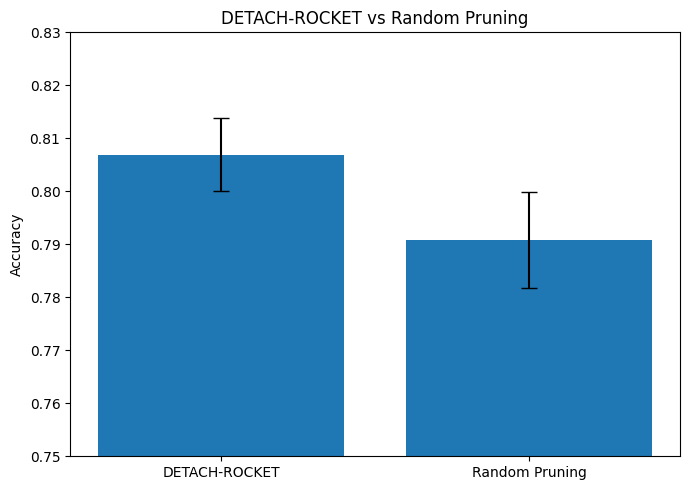

In [70]:
plt.figure(figsize=(7, 5))

plt.bar(
    summary_results["Method"],
    summary_results["Mean Accuracy"],
    yerr=summary_results["Std Accuracy"],
    capsize=6
)

plt.ylabel("Accuracy")
plt.title("DETACH-ROCKET vs Random Pruning")
plt.ylim(0.75, 0.83)
plt.tight_layout()

plt.savefig(
    "accuracy_mean_std_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

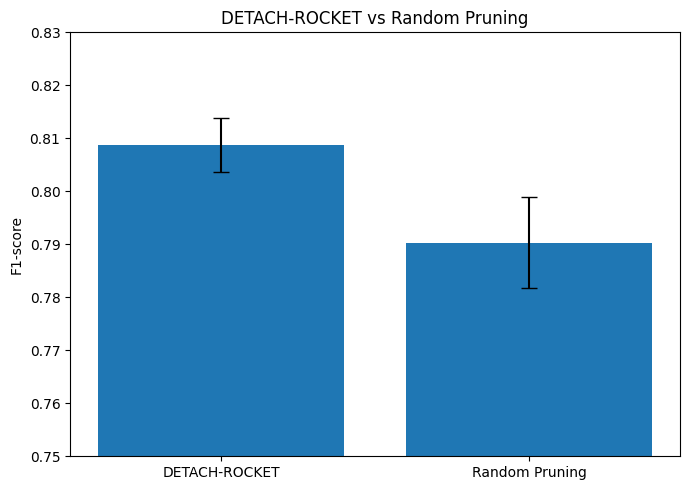

In [71]:
plt.figure(figsize=(7, 5))

plt.bar(
    summary_results["Method"],
    summary_results["Mean F1-score"],
    yerr=summary_results["Std F1-score"],
    capsize=6
)

plt.ylabel("F1-score")
plt.title("DETACH-ROCKET vs Random Pruning")
plt.ylim(0.75, 0.83)
plt.tight_layout()

plt.savefig(
    "f1_mean_std_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [72]:
report_table = summary_results.copy()

for column in [
    "Mean Accuracy",
    "Std Accuracy",
    "Mean F1-score",
    "Std F1-score"
]:
    report_table[column] = report_table[column] * 100

report_table = report_table.round(2)

report_table

,Method,Runs,Mean Accuracy,Std Accuracy,Mean F1-score,Std F1-score
0,DETACH-ROCKET,5,80.69,0.69,80.87,0.51
1,Random Pruning,10,79.07,0.90,79.03,0.86


In [73]:
report_table.to_csv(
    "report_table_percent.csv",
    index=False
)

print("Report table saved successfully")

Report table saved successfully


In [74]:
accuracy_improvement = (
    detach_runs_df["accuracy"].mean()
    - random_runs_df["accuracy"].mean()
) * 100

f1_improvement = (
    detach_runs_df["f1_score"].mean()
    - random_runs_df["f1_score"].mean()
) * 100

print("Accuracy improvement:", round(accuracy_improvement, 2), "percentage points")
print("F1-score improvement:", round(f1_improvement, 2), "percentage points")

Accuracy improvement: 1.62 percentage points
F1-score improvement: 1.85 percentage points


In [75]:
improvement_results = pd.DataFrame([
    {
        "Metric": "Accuracy",
        "Improvement_percentage_points": accuracy_improvement
    },
    {
        "Metric": "F1-score",
        "Improvement_percentage_points": f1_improvement
    }
])

improvement_results.to_csv(
    "detach_vs_random_improvement.csv",
    index=False
)

print("Improvement results saved successfully")

Improvement results saved successfully


In [76]:
raw_scaler = StandardScaler()

X_train_raw_scaled = raw_scaler.fit_transform(X_train)
X_test_raw_scaled = raw_scaler.transform(X_test)

print("Raw train shape:", X_train_raw_scaled.shape)
print("Raw test shape:", X_test_raw_scaled.shape)

Raw train shape: (3636, 500)
Raw test shape: (810, 500)


In [77]:
raw_ridge_model = RidgeClassifierCV(alphas=alphas)

start = perf_counter()

raw_ridge_model.fit(
    X_train_raw_scaled,
    y_train
)

raw_ridge_training_time = perf_counter() - start

start = perf_counter()

raw_ridge_pred = raw_ridge_model.predict(
    X_test_raw_scaled
)

raw_ridge_prediction_time = perf_counter() - start

raw_ridge_accuracy = accuracy_score(
    y_test,
    raw_ridge_pred
)

raw_ridge_f1 = f1_score(
    y_test,
    raw_ridge_pred
)

print("Raw Ridge Accuracy:", raw_ridge_accuracy)
print("Raw Ridge F1-score:", raw_ridge_f1)
print("Raw Ridge Training Time:", raw_ridge_training_time)
print("Raw Ridge Prediction Time:", raw_ridge_prediction_time)
print("Selected Alpha:", raw_ridge_model.alpha_)

Raw Ridge Accuracy: 0.4888888888888889
Raw Ridge F1-score: 0.47058823529411764
Raw Ridge Training Time: 0.42926509999961127
Raw Ridge Prediction Time: 0.0008947999999691092
Selected Alpha: 1000.0


In [78]:
raw_ridge_results = {
    "model": "Raw Ridge",
    "num_features": X_train_raw_scaled.shape[1],
    "accuracy": raw_ridge_accuracy,
    "f1_score": raw_ridge_f1,
    "training_time": raw_ridge_training_time,
    "prediction_time": raw_ridge_prediction_time,
    "alpha": raw_ridge_model.alpha_
}

raw_ridge_results

{'model': 'Raw Ridge',
 'num_features': 500,
 'accuracy': 0.4888888888888889,
 'f1_score': 0.47058823529411764,
 'training_time': 0.42926509999961127,
 'prediction_time': 0.0008947999999691092,
 'alpha': 1000.0}

In [79]:
comparison_df = pd.concat([
    comparison_df,
    pd.DataFrame([{
        "Model": "Raw Ridge",
        "Features": raw_ridge_results["num_features"],
        "Accuracy": raw_ridge_results["accuracy"],
        "F1-score": raw_ridge_results["f1_score"],
        "Prediction Time": raw_ridge_results["prediction_time"]
    }])
], ignore_index=True)

comparison_df

,Model,Features,Accuracy,F1-score,Prediction Time
0,Full ROCKET,20000,0.802469,0.805825,0.098957
1,DETACH-ROCKET,789,0.814815,0.815271,0.079983
2,Random Pruning,789,0.800000,0.797500,0.002736
3,Raw Ridge,500,0.488889,0.470588,0.000895


In [80]:
comparison_df.to_csv(
    "comparison_results_4_models.csv",
    index=False
)

print("Four-model comparison saved successfully")

Four-model comparison saved successfully


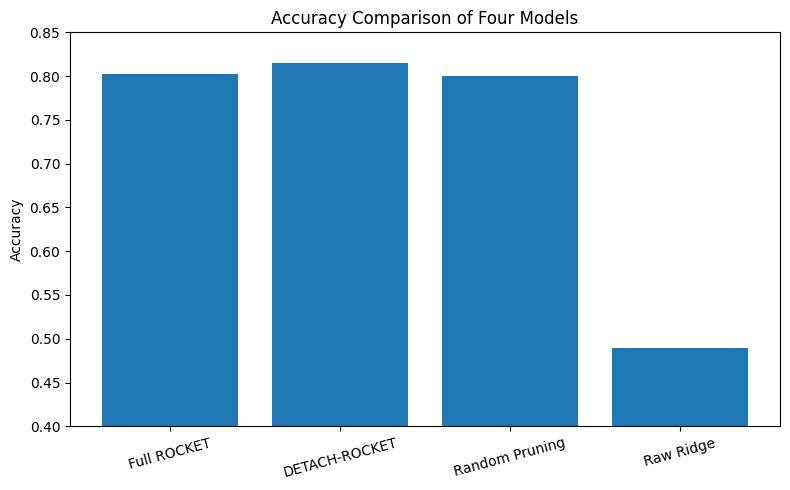

In [81]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Four Models")
plt.ylim(0.4, 0.85)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "four_model_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

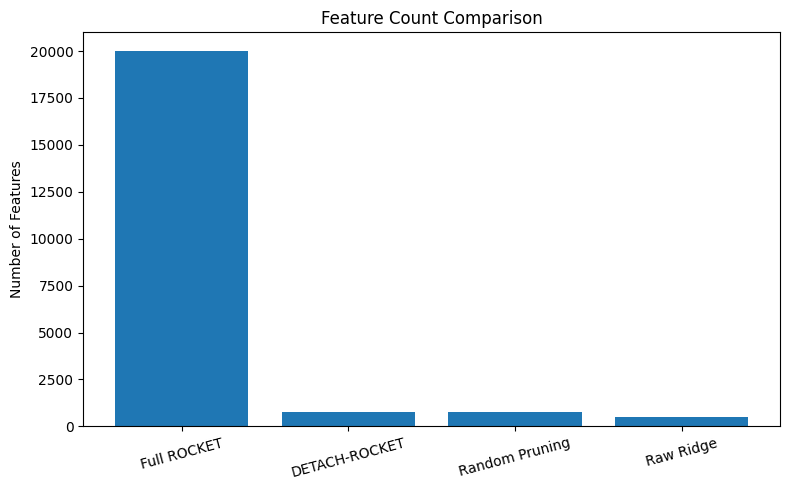

In [82]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_df["Model"],
    comparison_df["Features"]
)

plt.ylabel("Number of Features")
plt.title("Feature Count Comparison")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "four_model_feature_count_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
feature_reduction_percent = (
    1 - (
        detach_results["num_features"]
        / baseline_results["num_features"]
    )
) * 100

print(
    "Feature reduction:",
    round(feature_reduction_percent, 2),
    "%"
)

Feature reduction: 96.06 %


In [84]:
feature_reduction_results = pd.DataFrame([{
    "Full_ROCKET_Features": baseline_results["num_features"],
    "DETACH_Features": detach_results["num_features"],
    "Feature_Reduction_Percent": feature_reduction_percent
}])

feature_reduction_results.to_csv(
    "feature_reduction_results.csv",
    index=False
)

print("Feature reduction results saved successfully")

Feature reduction results saved successfully


In [85]:
final_report_table = comparison_df.copy()

final_report_table["Accuracy (%)"] = (
    final_report_table["Accuracy"] * 100
).round(2)

final_report_table["F1-score (%)"] = (
    final_report_table["F1-score"] * 100
).round(2)

final_report_table["Prediction Time (ms)"] = (
    final_report_table["Prediction Time"] * 1000
).round(3)

final_report_table = final_report_table[
    [
        "Model",
        "Features",
        "Accuracy (%)",
        "F1-score (%)",
        "Prediction Time (ms)"
    ]
]

final_report_table

,Model,Features,Accuracy (%),F1-score (%),Prediction Time (ms)
0,Full ROCKET,20000,80.25,80.58,98.957
1,DETACH-ROCKET,789,81.48,81.53,79.983
2,Random Pruning,789,80.00,79.75,2.736
3,Raw Ridge,500,48.89,47.06,0.895


In [86]:
final_report_table.to_csv(
    "final_report_table.csv",
    index=False
)

print("Final report table saved successfully")

Final report table saved successfully


In [87]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

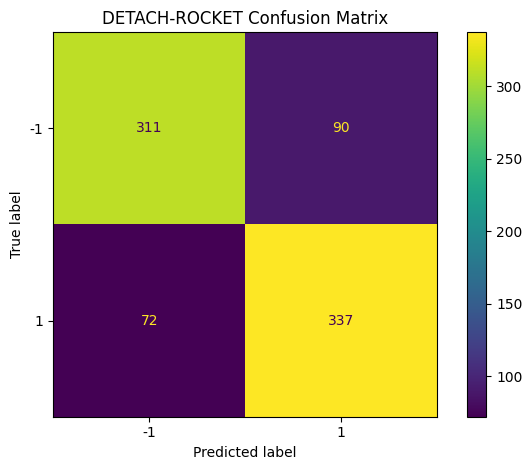

In [88]:
detach_cm = confusion_matrix(
    y_test,
    detach_seed_pred,
    labels=[-1, 1]
)

display = ConfusionMatrixDisplay(
    confusion_matrix=detach_cm,
    display_labels=[-1, 1]
)

display.plot()
plt.title("DETACH-ROCKET Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "detach_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [89]:
print(detach_cm)

[[311  90]
 [ 72 337]]


In [90]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        detach_seed_pred,
        labels=[-1, 1],
        digits=4
    )
)

              precision    recall  f1-score   support

          -1     0.8120    0.7756    0.7934       401
           1     0.7892    0.8240    0.8062       409

    accuracy                         0.8000       810
   macro avg     0.8006    0.7998    0.7998       810
weighted avg     0.8005    0.8000    0.7999       810



In [91]:
report_text = classification_report(
    y_test,
    detach_seed_pred,
    labels=[-1, 1],
    digits=4
)

with open(
    "detach_classification_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(report_text)

print("Classification report saved successfully")

Classification report saved successfully


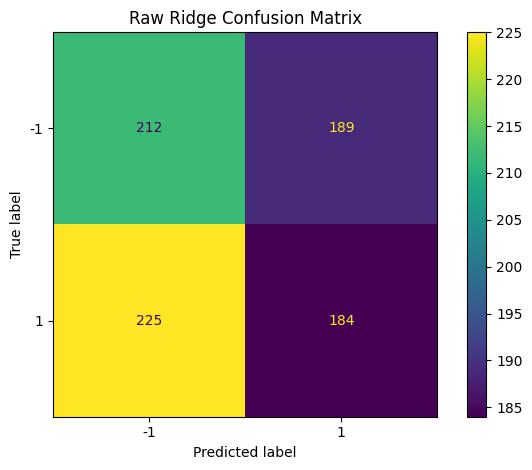

In [92]:
raw_ridge_cm = confusion_matrix(
    y_test,
    raw_ridge_pred,
    labels=[-1, 1]
)

display = ConfusionMatrixDisplay(
    confusion_matrix=raw_ridge_cm,
    display_labels=[-1, 1]
)

display.plot()
plt.title("Raw Ridge Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "raw_ridge_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [93]:
print(raw_ridge_cm)

[[212 189]
 [225 184]]


In [94]:
print(
    classification_report(
        y_test,
        raw_ridge_pred,
        labels=[-1, 1],
        digits=4
    )
)

              precision    recall  f1-score   support

          -1     0.4851    0.5287    0.5060       401
           1     0.4933    0.4499    0.4706       409

    accuracy                         0.4889       810
   macro avg     0.4892    0.4893    0.4883       810
weighted avg     0.4893    0.4889    0.4881       810



In [95]:
raw_report_text = classification_report(
    y_test,
    raw_ridge_pred,
    labels=[-1, 1],
    digits=4
)

with open(
    "raw_ridge_classification_report.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(raw_report_text)

print("Raw Ridge classification report saved successfully")

Raw Ridge classification report saved successfully


In [96]:
classwise_summary = pd.DataFrame([
    {
        "Model": "DETACH-ROCKET",
        "Class": "-1",
        "Precision": 0.8120,
        "Recall": 0.7756,
        "F1-score": 0.7934
    },
    {
        "Model": "DETACH-ROCKET",
        "Class": "1",
        "Precision": 0.7892,
        "Recall": 0.8240,
        "F1-score": 0.8062
    },
    {
        "Model": "Raw Ridge",
        "Class": "-1",
        "Precision": 0.4851,
        "Recall": 0.5287,
        "F1-score": 0.5060
    },
    {
        "Model": "Raw Ridge",
        "Class": "1",
        "Precision": 0.4933,
        "Recall": 0.4499,
        "F1-score": 0.4706
    }
])

classwise_summary

,Model,Class,Precision,Recall,F1-score
0,DETACH-ROCKET,-1,0.8120,0.7756,0.7934
1,DETACH-ROCKET,1,0.7892,0.8240,0.8062
2,Raw Ridge,-1,0.4851,0.5287,0.5060
3,Raw Ridge,1,0.4933,0.4499,0.4706


In [97]:
classwise_summary.to_csv(
    "classwise_summary.csv",
    index=False
)

print("Classwise summary saved successfully")

Classwise summary saved successfully


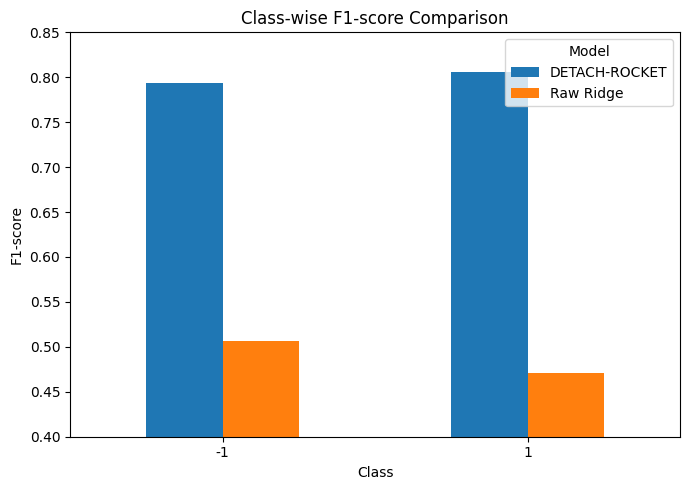

In [98]:
pivot_f1 = classwise_summary.pivot(
    index="Class",
    columns="Model",
    values="F1-score"
)

pivot_f1.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.ylabel("F1-score")
plt.title("Class-wise F1-score Comparison")
plt.xticks(rotation=0)
plt.ylim(0.4, 0.85)
plt.tight_layout()

plt.savefig(
    "classwise_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [99]:
pivot_f1.to_csv(
    "classwise_f1_pivot.csv"
)

print("Class-wise F1 pivot saved successfully")

Class-wise F1 pivot saved successfully


In [100]:
project_summary = f"""
FordB Classification Summary

Full ROCKET:
- Features: {baseline_results['num_features']}
- Accuracy: {baseline_results['accuracy'] * 100:.2f}%
- F1-score: {baseline_results['f1_score'] * 100:.2f}%

DETACH-ROCKET:
- Selected features: {detach_results['num_features']}
- Feature reduction: {feature_reduction_percent:.2f}%
- Mean Accuracy over 5 runs: {detach_runs_df['accuracy'].mean() * 100:.2f}% ± {detach_runs_df['accuracy'].std() * 100:.2f}%
- Mean F1-score over 5 runs: {detach_runs_df['f1_score'].mean() * 100:.2f}% ± {detach_runs_df['f1_score'].std() * 100:.2f}%

Random Pruning:
- Selected features: {selected_features}
- Mean Accuracy over 10 runs: {random_runs_df['accuracy'].mean() * 100:.2f}% ± {random_runs_df['accuracy'].std() * 100:.2f}%
- Mean F1-score over 10 runs: {random_runs_df['f1_score'].mean() * 100:.2f}% ± {random_runs_df['f1_score'].std() * 100:.2f}%

Raw Ridge:
- Features: {raw_ridge_results['num_features']}
- Accuracy: {raw_ridge_results['accuracy'] * 100:.2f}%
- F1-score: {raw_ridge_results['f1_score'] * 100:.2f}%

DETACH improvement over Random Pruning:
- Accuracy: {accuracy_improvement:.2f} percentage points
- F1-score: {f1_improvement:.2f} percentage points
"""

with open(
    "project_summary.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(project_summary)

print(project_summary)
print("Project summary saved successfully")


FordB Classification Summary

Full ROCKET:
- Features: 20000
- Accuracy: 80.25%
- F1-score: 80.58%

DETACH-ROCKET:
- Selected features: 789
- Feature reduction: 96.06%
- Mean Accuracy over 5 runs: 80.69% ± 0.69%
- Mean F1-score over 5 runs: 80.87% ± 0.51%

Random Pruning:
- Selected features: 789
- Mean Accuracy over 10 runs: 79.07% ± 0.90%
- Mean F1-score over 10 runs: 79.03% ± 0.86%

Raw Ridge:
- Features: 500
- Accuracy: 48.89%
- F1-score: 47.06%

DETACH improvement over Random Pruning:
- Accuracy: 1.62 percentage points
- F1-score: 1.85 percentage points

Project summary saved successfully


In [101]:
import sys
import numpy as np
import pandas as pd
import sklearn
import sktime
import matplotlib

environment_info = f"""
Python: {sys.version}
NumPy: {np.__version__}
Pandas: {pd.__version__}
Scikit-learn: {sklearn.__version__}
sktime: {sktime.__version__}
Matplotlib: {matplotlib.__version__}
"""

with open(
    "environment_versions.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(environment_info)

print(environment_info)
print("Environment information saved successfully")


Python: 3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
NumPy: 1.26.4
Pandas: 2.2.3
Scikit-learn: 1.5.2
sktime: 0.30.0
Matplotlib: 3.10.9

Environment information saved successfully


In [102]:
requirements_text = """
numpy
pandas
scikit-learn
matplotlib
sktime==0.30.0
torch
pyts
"""

with open(
    "requirements.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(requirements_text.strip())

print("requirements.txt saved successfully")

requirements.txt saved successfully


In [103]:
from textwrap import dedent

readme_text = dedent("""
# DETACH-ROCKET on the FordB Dataset

## Project Overview

This project evaluates DETACH-ROCKET for binary time-series classification using the FordB dataset.

The study compares four approaches:

1. Full ROCKET with all 20,000 transformed features
2. DETACH-ROCKET feature selection
3. Random feature pruning using the same number of features selected by DETACH
4. RidgeClassifierCV applied directly to the raw time-series samples

## Dataset

FordB is a binary time-series classification dataset.

- Training samples: 3,636
- Test samples: 810
- Time points per sample: 500
- Classes: -1 and 1

## Main Results

- Full ROCKET features: 20,000
- DETACH-selected features: 789
- Feature reduction: 96.06%
- DETACH mean Accuracy over 5 runs: 80.69% ± 0.69%
- DETACH mean F1-score over 5 runs: 80.87% ± 0.51%
- Random pruning mean Accuracy over 10 runs: 79.07% ± 0.90%
- Random pruning mean F1-score over 10 runs: 79.03% ± 0.86%
- Raw Ridge Accuracy: 48.89%
- Raw Ridge F1-score: 47.06%

DETACH outperformed random pruning while retaining the same number of features. This indicates that its performance is related to informed feature selection rather than feature-count reduction alone.

## Installation

Create and activate a Python virtual environment, then install the required packages:

    pip install -r requirements.txt

## Experimental Pipeline

1. Load the FordB training and test sets.
2. Generate 20,000 ROCKET features.
3. Standardize the transformed features.
4. Train the Full ROCKET Ridge classifier.
5. Apply DETACH using a training-validation split.
6. Evaluate DETACH on the independent test set.
7. Compare DETACH with random pruning.
8. Compare ROCKET-based approaches with Ridge classification on raw data.
9. Report Accuracy, F1-score, feature count, prediction time, and confusion matrices.

## Main Output Files

### Result Tables

- comparison_results_4_models.csv
- final_report_table.csv
- summary_results.csv
- report_table_percent.csv
- feature_reduction_results.csv
- detach_vs_random_improvement.csv
- classwise_summary.csv

### Repeated Experiments

- detach_5_runs.csv
- random_pruning_10_runs.csv

### Figures

- accuracy_mean_std_comparison.png
- f1_mean_std_comparison.png
- four_model_accuracy_comparison.png
- four_model_f1_comparison.png
- four_model_feature_count_comparison.png
- detach_confusion_matrix.png
- raw_ridge_confusion_matrix.png
- classwise_f1_comparison.png

### Documentation

- project_summary.txt
- detach_classification_report.txt
- raw_ridge_classification_report.txt
- environment_versions.txt
- requirements.txt

## Reproducibility

Fixed random seeds were used for:

- ROCKET kernel generation
- Random feature selection
- Training-validation splitting

DETACH was evaluated using five ROCKET seeds. Random pruning was evaluated using ten random seeds.

## Conclusion

DETACH reduced the ROCKET feature space by 96.06% while maintaining competitive classification performance. It also outperformed random feature pruning with the same feature budget. The poor performance of Ridge classification on raw FordB signals demonstrates the importance of ROCKET feature extraction.
""").strip()

with open("README.md", "w", encoding="utf-8") as file:
    file.write(readme_text)

print("README.md saved successfully")

README.md saved successfully


In [104]:
Z_sub_raw, Z_val_raw, y_sub_clean, y_val_clean = train_test_split(
    Z_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Sub-train shape:", Z_sub_raw.shape)
print("Validation shape:", Z_val_raw.shape)
print("Test shape:", Z_test.shape)

Sub-train shape: (2908, 20000)
Validation shape: (728, 20000)
Test shape: (810, 20000)


In [105]:
from sklearn.model_selection import train_test_split

In [106]:
Z_sub_raw, Z_val_raw, y_sub_clean, y_val_clean = train_test_split(
    Z_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

print("Sub-train shape:", Z_sub_raw.shape)
print("Validation shape:", Z_val_raw.shape)
print("Test shape:", Z_test.shape)

Sub-train shape: (2908, 20000)
Validation shape: (728, 20000)
Test shape: (810, 20000)


In [110]:
clean_scaler = StandardScaler()

Z_sub_clean = clean_scaler.fit_transform(Z_sub_raw)
Z_val_clean = clean_scaler.transform(Z_val_raw)
Z_test_clean = clean_scaler.transform(Z_test)

print("Scaled sub-train:", Z_sub_clean.shape)
print("Scaled validation:", Z_val_clean.shape)
print("Scaled test:", Z_test_clean.shape)

Scaled sub-train: (2908, 20000)
Scaled validation: (728, 20000)
Scaled test: (810, 20000)


In [111]:
detach_clean_model = DetachMatrix(
    trade_off=0.1,
    recompute_alpha=False,
    verbose=True
)

detach_clean_model.fit(
    Z_sub_clean,
    y_sub_clean,
    Z_val_clean,
    y_val_clean
)

print("Clean DETACH fitted successfully.")

Fitting Full Model
TRAINING RESULTS Full Features:
Optimal Alpha Full Features: 4832.93
Train Accuraccy Full Features: 99.86%
-------------------------
Applying Sequential Feature Detachment
Step 1 out of 150
100.000% of features used
Step 2 out of 150
95.000% of features used
Step 3 out of 150
90.250% of features used
Step 4 out of 150
85.735% of features used
Step 5 out of 150
81.450% of features used
Step 6 out of 150
77.375% of features used
Step 7 out of 150
73.505% of features used
Step 8 out of 150
69.830% of features used
Step 9 out of 150
66.340% of features used
Step 10 out of 150
63.020% of features used
Step 11 out of 150
59.870% of features used
Step 12 out of 150
56.880% of features used
Step 13 out of 150
54.035% of features used
Step 14 out of 150
51.330% of features used
Step 15 out of 150
48.765% of features used
Step 16 out of 150
46.325% of features used
Step 17 out of 150
44.010% of features used
Step 18 out of 150
41.810% of features used
Step 19 out of 150
39.720

In [112]:
detach_clean_pred = detach_clean_model.predict(
    Z_test_clean
)

detach_clean_accuracy = accuracy_score(
    y_test,
    detach_clean_pred
)

detach_clean_f1 = f1_score(
    y_test,
    detach_clean_pred
)

print("Clean DETACH Accuracy:", detach_clean_accuracy)
print("Clean DETACH F1-score:", detach_clean_f1)

Clean DETACH Accuracy: 0.8148148148148148
Clean DETACH F1-score: 0.8152709359605911


In [113]:
clean_selected_features = detach_clean_model.support_.sum()

print("Selected features:", clean_selected_features)
print(
    "Feature reduction:",
    round(
        (1 - clean_selected_features / Z_sub_clean.shape[1]) * 100,
        2
    ),
    "%"
)

AttributeError: 'DetachMatrix' object has no attribute 'support_'

In [114]:
print([
    name for name in dir(detach_clean_model)
    if not name.startswith("_")
])

['fit', 'fit_fixed_percentage', 'fit_trade_off', 'fixed_percentage', 'multilabel_type', 'predict', 'recompute_alpha', 'score', 'trade_off', 'val_ratio', 'verbose']


In [115]:
print(detach_clean_model.__dict__)

{'_sfd_curve': array([0.94505495, 0.94505495, 0.94505495, 0.94642857, 0.94642857,
       0.94642857, 0.94642857, 0.94642857, 0.9478022 , 0.94642857,
       0.94642857, 0.94642857, 0.94642857, 0.94642857, 0.94642857,
       0.94642857, 0.94505495, 0.94642857, 0.94505495, 0.94642857,
       0.94505495, 0.94230769, 0.94230769, 0.94505495, 0.94230769,
       0.94230769, 0.94230769, 0.94368132, 0.9478022 , 0.94505495,
       0.94230769, 0.94505495, 0.94368132, 0.94505495, 0.94505495,
       0.94642857, 0.94505495, 0.94917582, 0.9478022 , 0.9478022 ,
       0.94642857, 0.9478022 , 0.94368132, 0.94368132, 0.94368132,
       0.94505495, 0.94505495, 0.94230769, 0.94230769, 0.94230769,
       0.94230769, 0.94368132, 0.94505495, 0.94093407, 0.94230769,
       0.94368132, 0.94368132, 0.94368132, 0.94230769, 0.93956044,
       0.94368132, 0.94642857, 0.9478022 , 0.9532967 , 0.95192308,
       0.9532967 , 0.94917582, 0.94642857, 0.9478022 , 0.9478022 ,
       0.9478022 , 0.9478022 , 0.94505495, 0.93

In [116]:
clean_selected_features = detach_clean_model._feature_mask.sum()

print("Selected features:", clean_selected_features)
print(
    "Feature reduction:",
    round(
        (1 - clean_selected_features / Z_sub_clean.shape[1]) * 100,
        2
    ),
    "%"
)

Selected features: 789
Feature reduction: 96.06 %


In [117]:
clean_detach_results = {
    "model": "Clean DETACH-ROCKET",
    "num_features": int(clean_selected_features),
    "accuracy": detach_clean_accuracy,
    "f1_score": detach_clean_f1,
    "feature_reduction_percent": (
        1 - clean_selected_features / Z_sub_clean.shape[1]
    ) * 100
}

clean_detach_results

{'model': 'Clean DETACH-ROCKET',
 'num_features': 789,
 'accuracy': 0.8148148148148148,
 'f1_score': 0.8152709359605911,
 'feature_reduction_percent': 96.055}

In [118]:
clean_detach_df = pd.DataFrame([clean_detach_results])

clean_detach_df.to_csv(
    "clean_detach_results.csv",
    index=False
)

print("Clean DETACH results saved successfully")

Clean DETACH results saved successfully


In [119]:
from sklearn.feature_selection import SelectKBest, f_classif

In [120]:
select_k_best = SelectKBest(
    score_func=f_classif,
    k=clean_selected_features
)

Z_sub_kbest = select_k_best.fit_transform(
    Z_sub_clean,
    y_sub_clean
)

Z_val_kbest = select_k_best.transform(
    Z_val_clean
)

Z_test_kbest = select_k_best.transform(
    Z_test_clean
)

print("KBest sub-train:", Z_sub_kbest.shape)
print("KBest validation:", Z_val_kbest.shape)
print("KBest test:", Z_test_kbest.shape)

KBest sub-train: (2908, 789)
KBest validation: (728, 789)
KBest test: (810, 789)


c:\Users\LOQ\Desktop\detach_rocket-main\detach_rocket-main\.venv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:112: UserWarning: Features [ 4346  4502 14552] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
c:\Users\LOQ\Desktop\detach_rocket-main\detach_rocket-main\.venv\lib\site-packages\sklearn\feature_selection\_univariate_selection.py:113: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [121]:
kbest_model = RidgeClassifierCV(alphas=alphas)

kbest_model.fit(
    Z_sub_kbest,
    y_sub_clean
)

kbest_pred = kbest_model.predict(
    Z_test_kbest
)

kbest_accuracy = accuracy_score(
    y_test,
    kbest_pred
)

kbest_f1 = f1_score(
    y_test,
    kbest_pred
)

print("SelectKBest Accuracy:", kbest_accuracy)
print("SelectKBest F1-score:", kbest_f1)
print("Selected Alpha:", kbest_model.alpha_)

SelectKBest Accuracy: 0.8061728395061728
SelectKBest F1-score: 0.8092345078979344
Selected Alpha: 215.44346900318823


In [122]:
kbest_results = {
    "model": "SelectKBest",
    "num_features": Z_sub_kbest.shape[1],
    "accuracy": kbest_accuracy,
    "f1_score": kbest_f1,
    "alpha": kbest_model.alpha_
}

kbest_results

{'model': 'SelectKBest',
 'num_features': 789,
 'accuracy': 0.8061728395061728,
 'f1_score': 0.8092345078979344,
 'alpha': 215.44346900318823}

In [123]:
kbest_df = pd.DataFrame([kbest_results])

kbest_df.to_csv(
    "select_kbest_results.csv",
    index=False
)

print("SelectKBest results saved successfully")

SelectKBest results saved successfully


In [124]:
clean_feature_selection_comparison = pd.DataFrame([
    {
        "Method": "DETACH-ROCKET",
        "Features": clean_detach_results["num_features"],
        "Accuracy": clean_detach_results["accuracy"],
        "F1-score": clean_detach_results["f1_score"]
    },
    {
        "Method": "SelectKBest",
        "Features": kbest_results["num_features"],
        "Accuracy": kbest_results["accuracy"],
        "F1-score": kbest_results["f1_score"]
    }
])

clean_feature_selection_comparison

,Method,Features,Accuracy,F1-score
0,DETACH-ROCKET,789,0.814815,0.815271
1,SelectKBest,789,0.806173,0.809235


In [125]:
clean_feature_selection_comparison.to_csv(
    "clean_feature_selection_comparison.csv",
    index=False
)

print("Clean feature-selection comparison saved successfully")

Clean feature-selection comparison saved successfully


In [126]:
kbest_accuracy_gap = (
    clean_detach_results["accuracy"]
    - kbest_results["accuracy"]
) * 100

kbest_f1_gap = (
    clean_detach_results["f1_score"]
    - kbest_results["f1_score"]
) * 100

print(
    "DETACH Accuracy advantage:",
    round(kbest_accuracy_gap, 2),
    "percentage points"
)

print(
    "DETACH F1-score advantage:",
    round(kbest_f1_gap, 2),
    "percentage points"
)

DETACH Accuracy advantage: 0.86 percentage points
DETACH F1-score advantage: 0.6 percentage points


In [127]:
detach_vs_kbest = pd.DataFrame([
    {
        "Metric": "Accuracy",
        "DETACH_advantage_percentage_points": kbest_accuracy_gap
    },
    {
        "Metric": "F1-score",
        "DETACH_advantage_percentage_points": kbest_f1_gap
    }
])

detach_vs_kbest.to_csv(
    "detach_vs_selectkbest_improvement.csv",
    index=False
)

print("DETACH vs SelectKBest improvement saved successfully")

DETACH vs SelectKBest improvement saved successfully


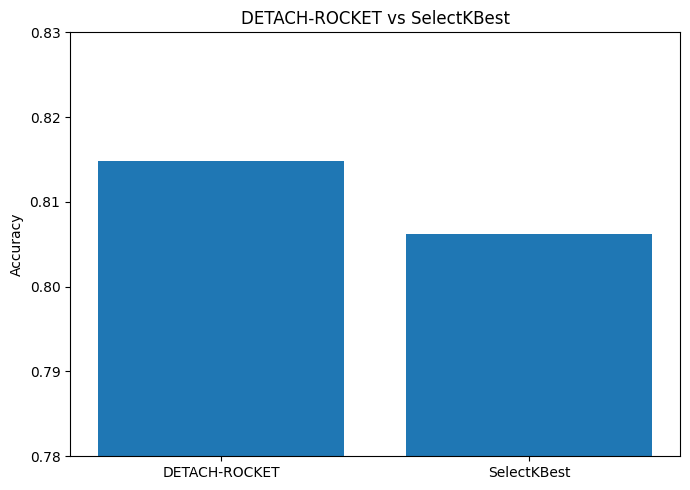

In [128]:
plt.figure(figsize=(7, 5))

plt.bar(
    clean_feature_selection_comparison["Method"],
    clean_feature_selection_comparison["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("DETACH-ROCKET vs SelectKBest")
plt.ylim(0.78, 0.83)
plt.tight_layout()

plt.savefig(
    "detach_vs_selectkbest_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

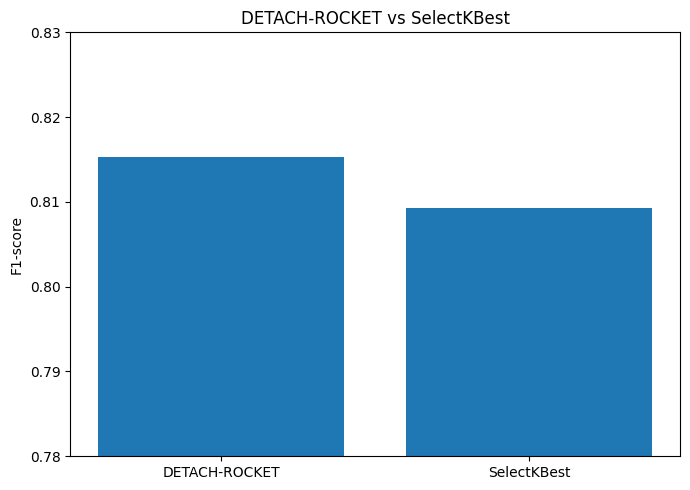

In [129]:
plt.figure(figsize=(7, 5))

plt.bar(
    clean_feature_selection_comparison["Method"],
    clean_feature_selection_comparison["F1-score"]
)

plt.ylabel("F1-score")
plt.title("DETACH-ROCKET vs SelectKBest")
plt.ylim(0.78, 0.83)
plt.tight_layout()

plt.savefig(
    "detach_vs_selectkbest_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [130]:
updated_comparison_df = pd.DataFrame([
    {
        "Model": "Full ROCKET",
        "Features": baseline_results["num_features"],
        "Accuracy": baseline_results["accuracy"],
        "F1-score": baseline_results["f1_score"]
    },
    {
        "Model": "DETACH-ROCKET",
        "Features": clean_detach_results["num_features"],
        "Accuracy": clean_detach_results["accuracy"],
        "F1-score": clean_detach_results["f1_score"]
    },
    {
        "Model": "Random Pruning",
        "Features": selected_features,
        "Accuracy": random_runs_df["accuracy"].mean(),
        "F1-score": random_runs_df["f1_score"].mean()
    },
    {
        "Model": "SelectKBest",
        "Features": kbest_results["num_features"],
        "Accuracy": kbest_results["accuracy"],
        "F1-score": kbest_results["f1_score"]
    },
    {
        "Model": "Raw Ridge",
        "Features": raw_ridge_results["num_features"],
        "Accuracy": raw_ridge_results["accuracy"],
        "F1-score": raw_ridge_results["f1_score"]
    }
])

updated_comparison_df

,Model,Features,Accuracy,F1-score
0,Full ROCKET,20000,0.802469,0.805825
1,DETACH-ROCKET,789,0.814815,0.815271
2,Random Pruning,789,0.790741,0.790256
3,SelectKBest,789,0.806173,0.809235
4,Raw Ridge,500,0.488889,0.470588


In [131]:
updated_comparison_df.to_csv(
    "updated_comparison_5_models.csv",
    index=False
)

print("Updated five-model comparison saved successfully")

Updated five-model comparison saved successfully


In [132]:
updated_report_table = updated_comparison_df.copy()

updated_report_table["Accuracy (%)"] = (
    updated_report_table["Accuracy"] * 100
).round(2)

updated_report_table["F1-score (%)"] = (
    updated_report_table["F1-score"] * 100
).round(2)

updated_report_table = updated_report_table[
    [
        "Model",
        "Features",
        "Accuracy (%)",
        "F1-score (%)"
    ]
]

updated_report_table

,Model,Features,Accuracy (%),F1-score (%)
0,Full ROCKET,20000,80.25,80.58
1,DETACH-ROCKET,789,81.48,81.53
2,Random Pruning,789,79.07,79.03
3,SelectKBest,789,80.62,80.92
4,Raw Ridge,500,48.89,47.06


In [133]:
updated_report_table.to_csv(
    "updated_report_table_percent.csv",
    index=False
)

print("Updated report table saved successfully")

Updated report table saved successfully


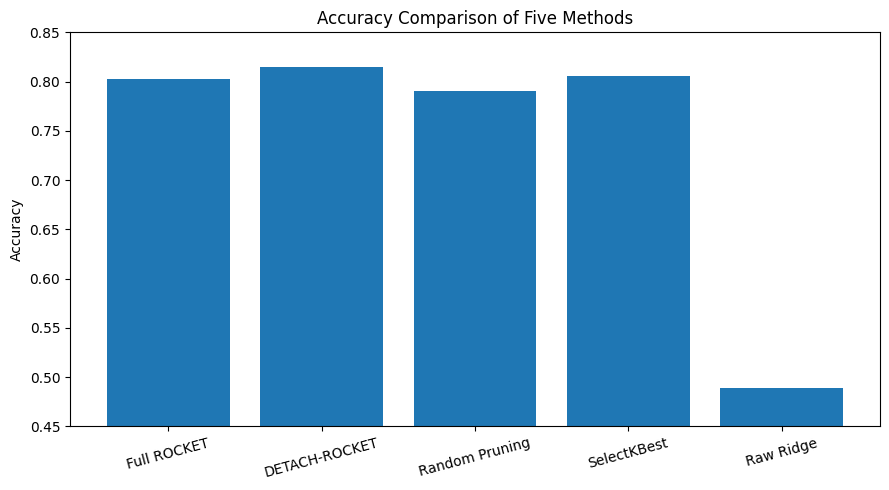

In [134]:
plt.figure(figsize=(9, 5))

plt.bar(
    updated_comparison_df["Model"],
    updated_comparison_df["Accuracy"]
)

plt.ylabel("Accuracy")
plt.title("Accuracy Comparison of Five Methods")
plt.ylim(0.45, 0.85)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "updated_five_model_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

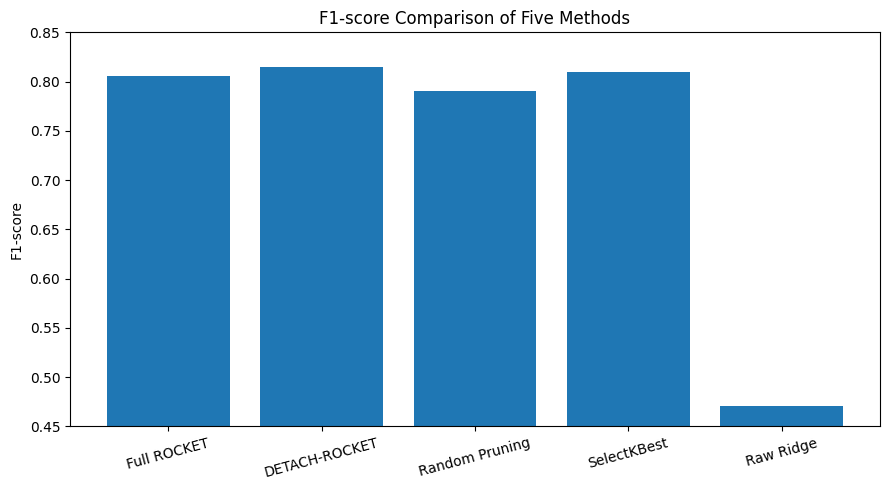

In [135]:
plt.figure(figsize=(9, 5))

plt.bar(
    updated_comparison_df["Model"],
    updated_comparison_df["F1-score"]
)

plt.ylabel("F1-score")
plt.title("F1-score Comparison of Five Methods")
plt.ylim(0.45, 0.85)
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "updated_five_model_f1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

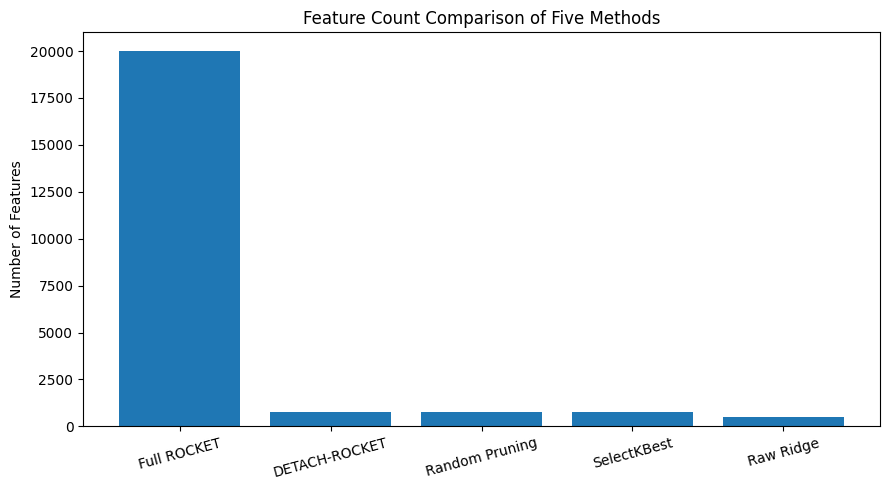

In [136]:
plt.figure(figsize=(9, 5))

plt.bar(
    updated_comparison_df["Model"],
    updated_comparison_df["Features"]
)

plt.ylabel("Number of Features")
plt.title("Feature Count Comparison of Five Methods")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig(
    "updated_five_model_feature_count.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [137]:
updated_project_summary = f"""
Updated FordB Project Summary

Full ROCKET:
- Features: {baseline_results['num_features']}
- Accuracy: {baseline_results['accuracy'] * 100:.2f}%
- F1-score: {baseline_results['f1_score'] * 100:.2f}%

Clean DETACH-ROCKET:
- Features: {clean_detach_results['num_features']}
- Accuracy: {clean_detach_results['accuracy'] * 100:.2f}%
- F1-score: {clean_detach_results['f1_score'] * 100:.2f}%
- Feature reduction: {clean_detach_results['feature_reduction_percent']:.2f}%

Random Pruning:
- Features: {selected_features}
- Mean Accuracy: {random_runs_df['accuracy'].mean() * 100:.2f}%
- Mean F1-score: {random_runs_df['f1_score'].mean() * 100:.2f}%

SelectKBest:
- Features: {kbest_results['num_features']}
- Accuracy: {kbest_results['accuracy'] * 100:.2f}%
- F1-score: {kbest_results['f1_score'] * 100:.2f}%

Raw Ridge:
- Features: {raw_ridge_results['num_features']}
- Accuracy: {raw_ridge_results['accuracy'] * 100:.2f}%
- F1-score: {raw_ridge_results['f1_score'] * 100:.2f}%

DETACH advantage over SelectKBest:
- Accuracy: {kbest_accuracy_gap:.2f} percentage points
- F1-score: {kbest_f1_gap:.2f} percentage points
"""

with open(
    "updated_project_summary.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(updated_project_summary)

print(updated_project_summary)
print("Updated project summary saved successfully")


Updated FordB Project Summary

Full ROCKET:
- Features: 20000
- Accuracy: 80.25%
- F1-score: 80.58%

Clean DETACH-ROCKET:
- Features: 789
- Accuracy: 81.48%
- F1-score: 81.53%
- Feature reduction: 96.06%

Random Pruning:
- Features: 789
- Mean Accuracy: 79.07%
- Mean F1-score: 79.03%

SelectKBest:
- Features: 789
- Accuracy: 80.62%
- F1-score: 80.92%

Raw Ridge:
- Features: 500
- Accuracy: 48.89%
- F1-score: 47.06%

DETACH advantage over SelectKBest:
- Accuracy: 0.86 percentage points
- F1-score: 0.60 percentage points

Updated project summary saved successfully


In [138]:
clean_random_seeds = list(range(10))
clean_random_runs = []

print("Number of clean random runs:", len(clean_random_seeds))
print("Feature budget:", clean_selected_features)

Number of clean random runs: 10
Feature budget: 789


In [139]:
for seed in clean_random_seeds:
    rng = np.random.default_rng(seed)

    random_indices = rng.choice(
        Z_sub_clean.shape[1],
        size=clean_selected_features,
        replace=False
    )

    model = RidgeClassifierCV(alphas=alphas)

    model.fit(
        Z_sub_clean[:, random_indices],
        y_sub_clean
    )

    predictions = model.predict(
        Z_test_clean[:, random_indices]
    )

    clean_random_runs.append({
        "seed": seed,
        "accuracy": accuracy_score(y_test, predictions),
        "f1_score": f1_score(y_test, predictions),
        "alpha": model.alpha_
    })

print("Completed clean random runs:", len(clean_random_runs))

Completed clean random runs: 10


In [140]:
clean_random_runs_df = pd.DataFrame(clean_random_runs)

print(clean_random_runs_df)

print("\nMean Accuracy:", clean_random_runs_df["accuracy"].mean())
print("Std Accuracy:", clean_random_runs_df["accuracy"].std())

print("\nMean F1-score:", clean_random_runs_df["f1_score"].mean())
print("Std F1-score:", clean_random_runs_df["f1_score"].std())

   seed  accuracy  f1_score   alpha
0     0  0.797531  0.790816  1000.0
1     1  0.781481  0.780669  1000.0
2     2  0.796296  0.797048  1000.0
3     3  0.770370  0.772059  1000.0
4     4  0.792593  0.791045  1000.0
5     5  0.795062  0.794554  1000.0
6     6  0.775309  0.775309  1000.0
7     7  0.787654  0.787654  1000.0
8     8  0.796296  0.799514  1000.0
9     9  0.798765  0.796504  1000.0

Mean Accuracy: 0.7891358024691357
Std Accuracy: 0.010093636027493576

Mean F1-score: 0.7885172802855659
Std F1-score: 0.009506148364343856


In [141]:
clean_random_runs_df.to_csv(
    "clean_random_pruning_10_runs.csv",
    index=False
)

print("Clean random pruning results saved successfully")

Clean random pruning results saved successfully


In [142]:
final_clean_comparison = pd.DataFrame([
    {
        "Method": "DETACH-ROCKET",
        "Features": clean_detach_results["num_features"],
        "Accuracy": clean_detach_results["accuracy"],
        "F1-score": clean_detach_results["f1_score"]
    },
    {
        "Method": "SelectKBest",
        "Features": kbest_results["num_features"],
        "Accuracy": kbest_results["accuracy"],
        "F1-score": kbest_results["f1_score"]
    },
    {
        "Method": "Random Pruning",
        "Features": clean_selected_features,
        "Accuracy": clean_random_runs_df["accuracy"].mean(),
        "F1-score": clean_random_runs_df["f1_score"].mean()
    }
])

final_clean_comparison

,Method,Features,Accuracy,F1-score
0,DETACH-ROCKET,789,0.814815,0.815271
1,SelectKBest,789,0.806173,0.809235
2,Random Pruning,789,0.789136,0.788517


In [143]:
final_clean_report_table = final_clean_comparison.copy()

final_clean_report_table["Accuracy (%)"] = (
    final_clean_report_table["Accuracy"] * 100
).round(2)

final_clean_report_table["F1-score (%)"] = (
    final_clean_report_table["F1-score"] * 100
).round(2)

final_clean_report_table = final_clean_report_table[
    ["Method", "Features", "Accuracy (%)", "F1-score (%)"]
]

final_clean_report_table.to_csv(
    "final_clean_feature_selection_comparison.csv",
    index=False
)

final_clean_report_table

,Method,Features,Accuracy (%),F1-score (%)
0,DETACH-ROCKET,789,81.48,81.53
1,SelectKBest,789,80.62,80.92
2,Random Pruning,789,78.91,78.85


In [144]:
final_clean_improvements = pd.DataFrame([
    {
        "Comparison": "DETACH vs SelectKBest",
        "Accuracy improvement (percentage points)": (
            clean_detach_results["accuracy"] - kbest_results["accuracy"]
        ) * 100,
        "F1 improvement (percentage points)": (
            clean_detach_results["f1_score"] - kbest_results["f1_score"]
        ) * 100
    },
    {
        "Comparison": "DETACH vs Random Pruning",
        "Accuracy improvement (percentage points)": (
            clean_detach_results["accuracy"]
            - clean_random_runs_df["accuracy"].mean()
        ) * 100,
        "F1 improvement (percentage points)": (
            clean_detach_results["f1_score"]
            - clean_random_runs_df["f1_score"].mean()
        ) * 100
    }
])

final_clean_improvements = final_clean_improvements.round(2)

final_clean_improvements.to_csv(
    "final_clean_improvements.csv",
    index=False
)

final_clean_improvements

,Comparison,Accuracy improvement (percentage points),F1 improvement (percentage points)
0,DETACH vs SelectKBest,0.86,0.60
1,DETACH vs Random Pruning,2.57,2.68


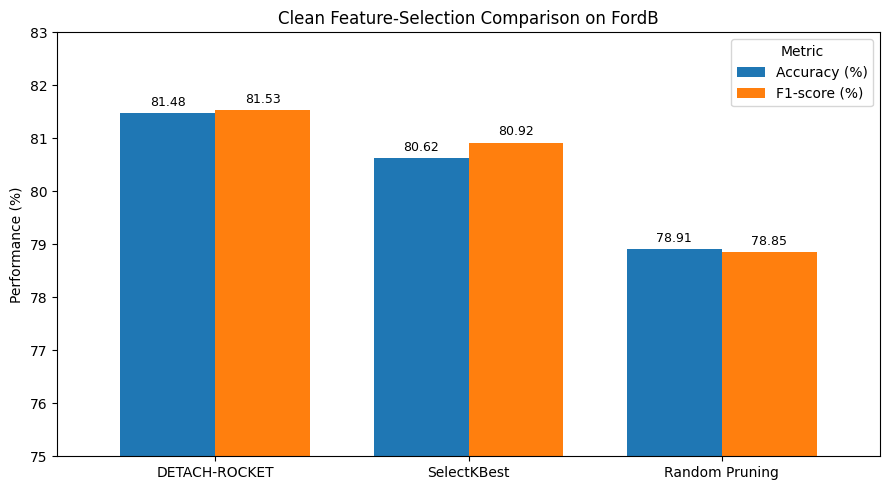

In [145]:
plot_data = final_clean_report_table.set_index("Method")[
    ["Accuracy (%)", "F1-score (%)"]
]

ax = plot_data.plot(
    kind="bar",
    figsize=(9, 5),
    width=0.75
)

ax.set_title("Clean Feature-Selection Comparison on FordB")
ax.set_ylabel("Performance (%)")
ax.set_xlabel("")
ax.set_ylim(75, 83)
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Metric")

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3,
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "final_clean_feature_selection_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [2]:
import pandas as pd

selected_features_count = 789
initial_features_count = 20000

compression_analysis = {
    "initial_features": initial_features_count,
    "selected_features": selected_features_count,
    "removed_features": (
        initial_features_count - selected_features_count
    ),
    "retained_features_percent": (
        selected_features_count / initial_features_count
    ) * 100,
    "feature_reduction_percent": (
        1 - selected_features_count / initial_features_count
    ) * 100,
    "compression_ratio": (
        initial_features_count / selected_features_count
    )
}

compression_analysis_df = pd.DataFrame(
    [compression_analysis]
).round(3)

compression_analysis_df.to_csv(
    "detach_compression_analysis.csv",
    index=False
)

compression_analysis_df

,initial_features,selected_features,removed_features,retained_features_percent,feature_reduction_percent,compression_ratio
0,20000,789,19211,3.945,96.055,25.349


In [3]:
from pathlib import Path

readme_text = r'''# DETACH-ROCKET on the FordB Dataset

## Project Overview

This project reproduces and extends the DETACH-ROCKET feature-selection
pipeline for binary time-series classification on the FordB dataset.

ROCKET transforms each time series into a high-dimensional representation
using random convolutional kernels. DETACH then performs sequential,
coefficient-based feature pruning to identify a compact subset of informative
ROCKET features.

The project evaluates five approaches:

1. Full ROCKET using all 20,000 transformed features
2. DETACH-ROCKET feature selection
3. SelectKBest with the same feature budget as DETACH
4. Random feature pruning with the same feature budget as DETACH
5. RidgeClassifierCV applied directly to the raw time-series samples

The main controlled feature-selection comparison uses the same sub-training
partition, validation partition, fitted scaler, test set, and feature budget
for DETACH, SelectKBest, and Random Pruning.

---

## Dataset

FordB is a binary time-series classification dataset from the UCR archive.

- Training samples: 3,636
- Test samples: 810
- Time points per sample: 500
- Classes: -1 and +1
- Missing values: none

Class distribution:

| Partition | Class -1 | Class +1 |
|---|---:|---:|
| Train | 1,860 | 1,776 |
| Test | 401 | 409 |

The two classes are approximately balanced.

---

## ROCKET Transformation

ROCKET applies 10,000 random convolutional kernels to each time series.

Two features are extracted from each kernel response:

- MAX: maximum convolution response
- PPV: proportion of positive values

This produces 20,000 features for each sample.

Transformation dimensions:

- Training set: 3,636 × 500 → 3,636 × 20,000
- Test set: 810 × 500 → 810 × 20,000

---

## Leakage-Free Experimental Pipeline

The final experiment uses a leakage-free preprocessing pipeline:

1. Load the original FordB train and test partitions.
2. Generate 20,000 ROCKET features.
3. Split the ROCKET training features into stratified sub-training and validation partitions.
4. Fit `StandardScaler` only on the sub-training partition.
5. Transform the validation and test partitions using the fitted scaler.
6. Run DETACH using the sub-training and validation partitions.
7. Fit SelectKBest only on the same sub-training partition.
8. Run Random Pruning using the same 789-feature budget.
9. Evaluate the final models on the independent test set.
10. Use the test set only for final evaluation.

Final split dimensions:

- Sub-training: 2,908 × 20,000
- Validation: 728 × 20,000
- Test: 810 × 20,000

After correcting the scaling order, the DETACH result remained unchanged.

---

## DETACH Configuration

The final DETACH model was configured as follows:

```python
DetachMatrix(
    trade_off=0.1,
    recompute_alpha=False,
    verbose=True
)
```

DETACH sequentially removes low-importance features based on the absolute
coefficients of a Ridge classifier. Validation performance is used to select
the final model size.

---

## Final Results

### Overall Model Summary

| Method | Features | Accuracy | F1-score |
|---|---:|---:|---:|
| Full ROCKET | 20,000 | 80.25% | 80.58% |
| DETACH-ROCKET | 789 | **81.48%** | **81.53%** |
| SelectKBest | 789 | 80.62% | 80.92% |
| Random Pruning | 789 | 78.91% ± 1.01% | 78.85% ± 0.95% |
| Raw Ridge | 500 | 48.89% | 47.06% |

Random Pruning results are reported as mean ± standard deviation over
10 independent random seeds.

---

## Controlled Feature-Selection Comparison

DETACH, SelectKBest, and Random Pruning were compared under the same
experimental conditions and with exactly 789 selected features.

| Method | Features | Accuracy | F1-score |
|---|---:|---:|---:|
| DETACH-ROCKET | 789 | **81.48%** | **81.53%** |
| SelectKBest | 789 | 80.62% | 80.92% |
| Random Pruning | 789 | 78.91% | 78.85% |

DETACH improvement over SelectKBest:

- Accuracy: +0.86 percentage points
- F1-score: +0.60 percentage points

DETACH improvement over Random Pruning:

- Accuracy: +2.57 percentage points
- F1-score: +2.68 percentage points

Because the three methods used the same feature budget and preprocessing
pipeline, the results provide a controlled comparison of the selected
feature subsets.

---

## Feature Compression

DETACH reduced the ROCKET feature space from 20,000 to 789 features.

- Initial features: 20,000
- Selected features: 789
- Removed features: 19,211
- Retained features: 3.945%
- Feature reduction: 96.055%
- Compression ratio: 25.35×

The final representation was approximately 25.35 times smaller than the
original ROCKET representation.

Test accuracy increased numerically from 80.25% for Full ROCKET to 81.48%
for DETACH-ROCKET.

---

## Interpretation

The results support four main observations:

1. ROCKET feature extraction is essential for FordB. Ridge classification
   on the raw 500-point signals achieved only 48.89% accuracy.

2. The 20,000-dimensional ROCKET representation contains substantial
   redundancy for this dataset.

3. Randomly retaining 789 features did not reproduce DETACH performance.

4. Under the controlled 789-feature comparison, DETACH achieved higher
   Accuracy and F1-score than both SelectKBest and Random Pruning.

---

## Extensions Added in This Project

Beyond reproducing the core DETACH-ROCKET pipeline, this project adds:

- F1-score evaluation
- Ridge classification on the raw time-series values
- SelectKBest with the same 789-feature budget
- Clean Random Pruning over 10 independent seeds
- Leakage-free scaling
- A controlled equal-budget feature-selection comparison
- Feature-compression analysis
- Reproducible CSV result tables
- Updated performance and feature-count figures
- Explicit separation between the original paper and the project extensions

---

## Installation

Create and activate a Python virtual environment, then install the required
packages:

```bash
pip install -r requirements.txt
```

The experiments were developed using Python 3.10.

---

## Notebook

The main experimental notebook is:

```text
examples/Detach_ROCKET_example_UCR.ipynb
```

---

## Main Output Files

### Final Result Tables

- `clean_detach_results.csv`
- `select_kbest_results.csv`
- `clean_random_pruning_10_runs.csv`
- `final_clean_feature_selection_comparison.csv`
- `final_clean_improvements.csv`
- `updated_comparison_5_models.csv`
- `updated_report_table_percent.csv`
- `detach_compression_analysis.csv`

### Final Figures

- `final_clean_feature_selection_comparison.png`
- `updated_five_model_accuracy.png`
- `updated_five_model_f1.png`
- `updated_five_model_feature_count.png`
- `detach_vs_selectkbest_accuracy.png`
- `detach_vs_selectkbest_f1.png`

### Documentation

- `updated_project_summary.txt`
- `environment_versions.txt`
- `requirements.txt`

Some earlier exploratory files may remain in the project directory, but the
files listed above contain the final leakage-free results used in the report
and presentation.

---

## Reproducibility

Fixed random seeds were used for:

- Training-validation splitting
- Random feature selection
- ROCKET kernel generation in repeated exploratory experiments

The final clean split used stratification and `random_state=42`.

Random Pruning was evaluated using 10 independent seeds:

```text
0, 1, 2, 3, 4, 5, 6, 7, 8, 9
```

The test set was not used for fitting the scaler, selecting features, or
choosing the final DETACH model size.

---

## Conclusion

DETACH-ROCKET reduced the FordB ROCKET feature space from 20,000 to 789
features, corresponding to a 96.055% reduction and a 25.35-fold compression.

The final DETACH model achieved:

- 81.48% Accuracy
- 81.53% F1-score

In the controlled comparison with the same 789-feature budget, DETACH
outperformed both SelectKBest and Random Pruning on the FordB test set.

These results show that targeted feature selection can produce a substantially
more compact ROCKET representation without sacrificing classification
performance on FordB.
'''

readme_path = Path("README.md")

readme_path.write_text(
    readme_text,
    encoding="utf-8"
)

print("README replaced successfully.")
print("Saved to:", readme_path.resolve())

README replaced successfully.
Saved to: C:\Users\LOQ\Desktop\detach_rocket-main\detach_rocket-main\examples\README.md


## Prepare Dataset Matrices

In [107]:
import numpy as np

# Create data matrices and remove possible rows with nans

print(f"Dataset Matrix Shape: ( # of instances , time series length )")
print(f" ")

# Train Matrix
X_train = current_dataset['data_train']
print(f"Train: {X_train.shape}")
non_nan_mask_train = ~np.isnan(X_train).any(axis=1)
non_inf_mask_train = ~np.isinf(X_train).any(axis=1)
mask_train = np.logical_and(non_nan_mask_train,non_inf_mask_train)
X_train = X_train[mask_train]
X_train = X_train.reshape(X_train.shape[0],1,X_train.shape[1])
y_train = current_dataset['target_train']
y_train = y_train[mask_train]

print(f" ")

# Test Matrix
X_test = current_dataset['data_test']
#print(f"Number of test instances: {len(X_test)}")
print(f"Test: {X_test.shape}")
non_nan_mask_test = ~np.isnan(X_test).any(axis=1)
non_inf_mask_test = ~np.isinf(X_test).any(axis=1)
mask_test = np.logical_and(non_nan_mask_test,non_inf_mask_test)
X_test = X_test[mask_test]
X_test = X_test.reshape(X_test.shape[0],1,X_test.shape[1])
y_test = current_dataset['target_test']
y_test = y_test[mask_test]

Dataset Matrix Shape: ( # of instances , time series length )
 
Train: (3636, 500)
 
Test: (810, 500)


## Train and Evaluate the Model

In [108]:
from detach_rocket.detach_classes import DetachRocket

np.random.seed(2)

# Select initial model characteristics
model_type = "rocket"
num_kernels = 10000

# Create model object
DetachRocketModel = DetachRocket(model_type, num_kernels=num_kernels)

# Trian Model
DetachRocketModel.fit(X_train,y_train)

# Evaluate Performance on Test Set
detach_test_score, full_test_score= DetachRocketModel.score(X_test,y_test)
print('Test Accuraccy Full Model: {:.2f}%'.format(100*full_test_score))
print('Test Accuraccy Detach-ROCKET: {:.2f}%'.format(100*detach_test_score))

TRAINING RESULTS Full ROCKET:
Optimal Alpha Full ROCKET: 4832.93
Train Accuraccy Full ROCKET: 99.78%
-------------------------
TRAINING RESULTS Detach Model:
Optimal Alpha Detach Model: 428.13
Train Accuraccy Detach Model: 96.97%
-------------------------
Test Accuraccy Full Model: 80.25%
Test Accuraccy Detach-ROCKET: 80.49%


## Plot SFD Curve and Optimal Model Selection

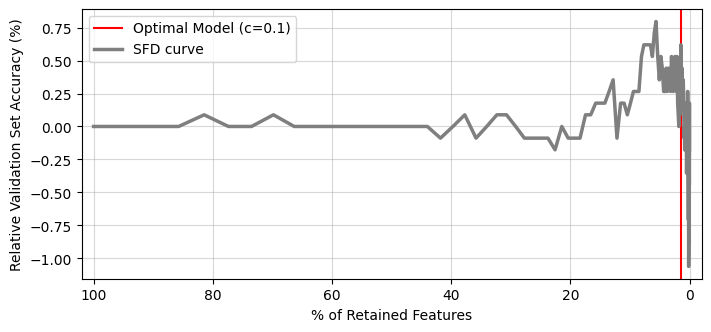

Optimal Model Size: 1.42% of full model


In [109]:
import matplotlib.pyplot as plt

percentage_vector = DetachRocketModel._percentage_vector
acc_curve = DetachRocketModel._sfd_curve

c = DetachRocketModel.trade_off

x=(percentage_vector) * 100
y=(acc_curve/acc_curve[0]-1) * 100

point_x = x[DetachRocketModel._max_index]
#point_y = y[DetachRocketModel._max_index]

plt.figure(figsize=(8,3.5))
plt.axvline(x = point_x, color = 'r',label=f'Optimal Model (c={c})')
plt.plot(x, y, label='SFD curve', linewidth=2.5, color='C7', alpha=1)
#plt.scatter(point_x, point_y, s=50, marker='o', label=f'Optimal point (c={c})')

plt.grid(True, linestyle='-', alpha=0.5)
plt.xlim(102,-2)
plt.xlabel('% of Retained Features')
plt.ylabel('Relative Validation Set Accuracy (%)')
plt.legend()
plt.show()

print('Optimal Model Size: {:.2f}% of full model'.format(point_x))